# Laboratorio 02 — Análisis de un dataset de pacientes con presupuesto de memoria

**Curso:** Ciencia de Datos Aplicada en Biomedicina  
**Autor:** Alejandro García Colorado  
**Fecha:** agosto de 2026

## Objetivo

Cargar, limpiar y analizar un conjunto de historias clínicas electrónicas sintéticas generado con Synthea, evaluando el costo de memoria de las decisiones de representación de los datos.

Para esto se procedió a generar una población con **Synthea 4.0.0** empleando una semilla fija. El dataset generado contiene 23,006 registros de pacientes, 1,399,646 encuentros y 17,677,231 observaciones clínicas.

## 0. Comprobaciones de la existencia de los archivos

Antes de comenzar con el pipeline necesitamos ubicar los archivos generados por Synthea.

In [6]:
from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

DATA_DIR = Path("data/synthea_20000/csv")

PATIENTS_FILE = DATA_DIR / "patients.csv"
ENCOUNTERS_FILE = DATA_DIR / "encounters.csv"
OBSERVATIONS_FILE = DATA_DIR / "observations.csv"

for archivo in [PATIENTS_FILE, ENCOUNTERS_FILE, OBSERVATIONS_FILE]:
    if not archivo.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {archivo}")

print("Los tres archivos fueron localizados correctamente.")

Los tres archivos fueron localizados correctamente.


In [7]:
def bytes_a_mb(numero_bytes):
    """Convierte bytes a MiB."""
    return numero_bytes / (1024 ** 2)


inventario_archivos = pd.DataFrame(
    {
        "archivo": [
            PATIENTS_FILE.name,
            ENCOUNTERS_FILE.name,
            OBSERVATIONS_FILE.name,
        ],
        "tamaño_disco_MiB": [
            bytes_a_mb(PATIENTS_FILE.stat().st_size),
            bytes_a_mb(ENCOUNTERS_FILE.stat().st_size),
            bytes_a_mb(OBSERVATIONS_FILE.stat().st_size),
        ],
    }
)

display(inventario_archivos)

,archivo,tamaño_disco_MiB
0,patients.csv,6.571
1,encounters.csv,443.404
2,observations.csv,"2,973.110"


**Nota:** Un 1 MiB = 1024^2 bytes

## 1. Carga con tipos de datos explícitos

### Clasificación de las variables de pacientes

La naturaleza conceptual de una variable no se determina únicamente por su apariencia. Por ejemplo, un código postal contiene dígitos, pero no representa una cantidad sobre la cual tenga sentido calcular una media.

Las columnas principales de `patients.csv` se clasificaron de la siguiente manera:

| Columna | Naturaleza conceptual | Representación inicial propuesta |
|---|---|---|
| `Id` | Identificador único del paciente | Cadena de texto |
| `BIRTHDATE` | Fecha de nacimiento | Fecha |
| `DEATHDATE` | Fecha de defunción, posiblemente faltante | Fecha |
| `GENDER` | Variable categórica nominal | Categoría |
| `RACE` | Variable categórica nominal | Categoría |
| `ETHNICITY` | Variable categórica nominal | Categoría |
| `CITY` | Variable categórica geográfica | Categoría o cadena |
| `STATE` | Variable categórica geográfica | Categoría |

Los identificadores no deben convertirse a números porque sus caracteres no representan magnitudes. Las variables `GENDER`, `RACE`, `ETHNICITY` y `STATE` tienen un conjunto pequeño de valores repetidos, por lo que son candidatas naturales para el tipo `category`. `CITY` requiere una evaluación adicional debido a su mayor cardinalidad.

In [8]:
inicio = time.perf_counter()

patients_naive = pd.read_csv(PATIENTS_FILE)

tiempo_patients_naive = time.perf_counter() - inicio
memoria_patients_naive = patients_naive.memory_usage(deep=True).sum()

print(f"Dimensiones: {patients_naive.shape}")
print(f"Tiempo de carga: {tiempo_patients_naive:.3f} s")
print(
    f"Memoria profunda: "
    f"{bytes_a_mb(memoria_patients_naive):,.3f} MiB"
)

display(patients_naive.head())

Dimensiones: (23006, 28)
Tiempo de carga: 0.097 s
Memoria profunda: 26.965 MiB


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,2021-04-06,NaN,999-75-4799,NaN,NaN,NaN,Roberto515,Denny560,Schultz619,NaN,NaN,NaN,white,nonhispanic,M,Peabody Massachusetts US,565 Hauck Glen,West Springfield,Massachusetts,Hampden County,"25,013.000",1089,42.140,-72.614,"17,377.730",0.000,51766
1,13820a8e-87d9-ded4-4a41-1174dbbfbba0,2018-12-01,NaN,999-10-6882,NaN,NaN,NaN,Leandro563,Emerson869,Tromp100,NaN,NaN,NaN,white,nonhispanic,M,Easton Massachusetts US,497 Leannon Overpass,Kingston,Massachusetts,Plymouth County,"25,023.000",2364,42.026,-70.762,"12,098.610",0.000,85370
2,f3c2f1e5-6ad2-5943-d219-e0b4d8d8e74a,2013-11-15,NaN,999-51-8269,NaN,NaN,NaN,Javier97,Don899,Williamson769,NaN,NaN,NaN,white,nonhispanic,M,Cambridge Massachusetts US,957 Heathcote Fork,Lynnfield,Massachusetts,Essex County,"25,009.000",1940,42.571,-71.006,"27,929.800","44,300.450",448143
3,623756ed-a048-c48a-90f2-1b77cd834e31,1998-01-09,NaN,999-26-6561,S99915749,X1895005X,Mr.,Vincent299,Irving123,Mertz280,NaN,NaN,M,white,nonhispanic,M,Lynn Massachusetts US,793 Wisoky Vista,Chicopee,Massachusetts,Hampden County,"25,013.000",1022,42.131,-72.568,"102,850.460","599,391.750",109424
4,5ab754d3-5e69-2073-9c45-3028632cbb06,1999-04-27,NaN,999-49-5667,S99986562,X20679900X,Ms.,Ghislaine112,NaN,Flatley871,NaN,NaN,NaN,white,hispanic,F,Freetown Massachusetts US,794 Eichmann Orchard,Clinton,Massachusetts,Worcester County,"25,027.000",1510,42.421,-71.671,"121,460.220","736,923.850",37173


In [9]:
# Mostrar estructura y memoria del DataFrame
patients_naive.info(memory_usage="deep")

# Crear auditoría por columna
auditoria_patients_naive = pd.DataFrame(
    {
        "dtype_inferido": patients_naive.dtypes.astype(str),
        "n_unicos": patients_naive.nunique(dropna=True),
        "n_faltantes": patients_naive.isna().sum(),
        "memoria_MiB": (
            patients_naive.memory_usage(
                deep=True,
                index=False,
            )
            / (1024 ** 2)
        ),
    }
).sort_values(
    "memoria_MiB",
    ascending=False,
)

display(auditoria_patients_naive)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23006 entries, 0 to 23005
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   23006 non-null  object 
 1   BIRTHDATE            23006 non-null  object 
 2   DEATHDATE            3006 non-null   object 
 3   SSN                  23006 non-null  object 
 4   DRIVERS              19128 non-null  object 
 5   PASSPORT             17977 non-null  object 
 6   PREFIX               18533 non-null  object 
 7   FIRST                23006 non-null  object 
 8   MIDDLE               18432 non-null  object 
 9   LAST                 23006 non-null  object 
 10  SUFFIX               262 non-null    object 
 11  MAIDEN               6225 non-null   object 
 12  MARITAL              15543 non-null  object 
 13  RACE                 23006 non-null  object 
 14  ETHNICITY            23006 non-null  object 
 15  GENDER               23006 non-null 

,dtype_inferido,n_unicos,n_faltantes,memoria_MiB
Id,object,23006,0,1.865
BIRTHPLACE,object,519,0,1.679
ADDRESS,object,23006,0,1.540
COUNTY,object,14,0,1.399
STATE,object,1,0,1.360
SSN,object,22714,0,1.316
ETHNICITY,object,2,0,1.309
BIRTHDATE,object,14716,0,1.294
LAST,object,1026,0,1.291
FIRST,object,4893,0,1.276


In [10]:
auditoria_patients_naive = pd.DataFrame(
    {
        "dtype_inferido": patients_naive.dtypes.astype(str),
        "n_unicos": patients_naive.nunique(dropna=True),
        "n_faltantes": patients_naive.isna().sum(),
        "memoria_MiB": patients_naive.memory_usage(
            deep=True,
            index=False
        ) / (1024 ** 2),
    }
).sort_values("memoria_MiB", ascending=False)

display(auditoria_patients_naive)

,dtype_inferido,n_unicos,n_faltantes,memoria_MiB
Id,object,23006,0,1.865
BIRTHPLACE,object,519,0,1.679
ADDRESS,object,23006,0,1.540
COUNTY,object,14,0,1.399
STATE,object,1,0,1.360
SSN,object,22714,0,1.316
ETHNICITY,object,2,0,1.309
BIRTHDATE,object,14716,0,1.294
LAST,object,1026,0,1.291
FIRST,object,4893,0,1.276


In [11]:
import sys
print(sys.executable)

/opt/anaconda3/envs/cdb/bin/python


In [12]:
# Tipos explícitos para patients.csv
dtypes_patients = {
    # Identificadores y códigos
    "Id": "string[pyarrow]",
    "SSN": "string[pyarrow]",
    "DRIVERS": "string[pyarrow]",
    "PASSPORT": "string[pyarrow]",
    "FIPS": "string[pyarrow]",
    "ZIP": "string[pyarrow]",

    # Texto de alta cardinalidad
    "FIRST": "string[pyarrow]",
    "MIDDLE": "string[pyarrow]",
    "LAST": "string[pyarrow]",
    "MAIDEN": "string[pyarrow]",
    "ADDRESS": "string[pyarrow]",

    # Variables categóricas
    "PREFIX": "category",
    "SUFFIX": "category",
    "MARITAL": "category",
    "RACE": "category",
    "ETHNICITY": "category",
    "GENDER": "category",
    "BIRTHPLACE": "category",
    "CITY": "category",
    "STATE": "category",
    "COUNTY": "category",

    # Variables numéricas
    "LAT": "float32",
    "LON": "float32",
    "HEALTHCARE_EXPENSES": "float32",
    "HEALTHCARE_COVERAGE": "float32",
    "INCOME": "Int32",
}

inicio = time.perf_counter()

patients_opt = pd.read_csv(
    PATIENTS_FILE,
    dtype=dtypes_patients,
    parse_dates=["BIRTHDATE", "DEATHDATE"],
)

tiempo_patients_opt = time.perf_counter() - inicio
memoria_patients_opt = patients_opt.memory_usage(deep=True).sum()

print(f"Dimensiones: {patients_opt.shape}")
print(f"Tiempo de carga: {tiempo_patients_opt:.3f} s")
print(
    f"Memoria profunda: "
    f"{bytes_a_mb(memoria_patients_opt):,.3f} MiB"
)

patients_opt.info(memory_usage="deep")

Dimensiones: (23006, 28)
Tiempo de carga: 0.106 s
Memoria profunda: 5.751 MiB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23006 entries, 0 to 23005
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   23006 non-null  string        
 1   BIRTHDATE            23006 non-null  datetime64[ns]
 2   DEATHDATE            3006 non-null   datetime64[ns]
 3   SSN                  23006 non-null  string        
 4   DRIVERS              19128 non-null  string        
 5   PASSPORT             17977 non-null  string        
 6   PREFIX               18533 non-null  category      
 7   FIRST                23006 non-null  string        
 8   MIDDLE               18432 non-null  string        
 9   LAST                 23006 non-null  string        
 10  SUFFIX               262 non-null    category      
 11  MAIDEN               6225 non-null   string        
 12  MARITAL   

In [13]:
comparacion_patients = pd.DataFrame(
    {
        "archivo": ["patients.csv"],
        "filas": [len(patients_opt)],
        "columnas": [patients_opt.shape[1]],
        "memoria_ingenua_MiB": [
            bytes_a_mb(memoria_patients_naive)
        ],
        "memoria_optimizada_MiB": [
            bytes_a_mb(memoria_patients_opt)
        ],
        "tiempo_ingenuo_s": [tiempo_patients_naive],
        "tiempo_optimizado_s": [tiempo_patients_opt],
    }
)

comparacion_patients["reduccion_porcentaje"] = (
    1
    - comparacion_patients["memoria_optimizada_MiB"]
    / comparacion_patients["memoria_ingenua_MiB"]
) * 100

display(comparacion_patients)

,archivo,filas,columnas,memoria_ingenua_MiB,memoria_optimizada_MiB,tiempo_ingenuo_s,tiempo_optimizado_s,reduccion_porcentaje
0,patients.csv,23006,28,26.965,5.751,0.097,0.106,78.672


**Nota:** La carga con tipos explícitos redujo el consumo de memoria de `patients.csv` de 26.965 a 5.751 MiB, equivalente a una reducción del 78.67%. La carga optimizada fue ligeramente más lenta, debido al costo de convertir fechas y construir variables categóricas. Sin embargo, permitió representar correctamente identificadores y códigos como texto, conservar los ceros iniciales de `ZIP` y reducir considerablemente la memoria ocupada por valores categóricos repetidos.

In [14]:
#Verificamos que el manejo del dataset no alteró la estructura
assert patients_naive.shape == patients_opt.shape
assert patients_opt["Id"].is_unique
assert patients_opt["Id"].notna().all()

display(
    patients_opt[
        ["Id", "BIRTHDATE", "DEATHDATE", "ZIP", "RACE", "GENDER"]
    ].head()
)

,Id,BIRTHDATE,DEATHDATE,ZIP,RACE,GENDER
0,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,2021-04-06,NaT,01089,white,M
1,13820a8e-87d9-ded4-4a41-1174dbbfbba0,2018-12-01,NaT,02364,white,M
2,f3c2f1e5-6ad2-5943-d219-e0b4d8d8e74a,2013-11-15,NaT,01940,white,M
3,623756ed-a048-c48a-90f2-1b77cd834e31,1998-01-09,NaT,01022,white,M
4,5ab754d3-5e69-2073-9c45-3028632cbb06,1999-04-27,NaT,01510,white,F


In [15]:
del patients_naive
gc.collect()

print("patients_naive fue eliminado de la memoria.")

patients_naive fue eliminado de la memoria.


In [16]:
#Confirmamos que la se eliminará la carga ingenua
"patients_naive" in globals()

False

### Carga de encuentros clínicos

`encounters.csv` contiene un registro por encuentro clínico. Las columnas `Id`, `PATIENT`, `ORGANIZATION`, `PROVIDER` y `PAYER` son identificadores, mientras que `START` y `STOP` representan instantes temporales. `ENCOUNTERCLASS`, `DESCRIPTION` y `REASONDESCRIPTION` son variables categóricas. Los códigos clínicos deben tratarse como texto, aunque estén formados únicamente por dígitos, porque no representan magnitudes numéricas.

In [17]:
inicio = time.perf_counter()

encounters_naive = pd.read_csv(ENCOUNTERS_FILE)

tiempo_encounters_naive = time.perf_counter() - inicio
memoria_encounters_naive = encounters_naive.memory_usage(
    deep=True
).sum()

print(f"Dimensiones: {encounters_naive.shape}")
print(f"Tiempo de carga: {tiempo_encounters_naive:.3f} s")
print(
    f"Memoria profunda: "
    f"{bytes_a_mb(memoria_encounters_naive):,.3f} MiB"
)

encounters_naive.info(memory_usage="deep")

Dimensiones: (1399646, 15)
Tiempo de carga: 3.187 s
Memoria profunda: 1,079.623 MiB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399646 entries, 0 to 1399645
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Id                   1399646 non-null  object 
 1   START                1399646 non-null  object 
 2   STOP                 1399646 non-null  object 
 3   PATIENT              1399646 non-null  object 
 4   ORGANIZATION         1399646 non-null  object 
 5   PROVIDER             1399646 non-null  object 
 6   PAYER                1399646 non-null  object 
 7   ENCOUNTERCLASS       1399646 non-null  object 
 8   CODE                 1399646 non-null  int64  
 9   DESCRIPTION          1399646 non-null  object 
 10  BASE_ENCOUNTER_COST  1399646 non-null  float64
 11  TOTAL_CLAIM_COST     1399646 non-null  float64
 12  PAYER_COVERAGE       1399646 non-null  float64
 13  REASONCODE        

In [18]:
display(encounters_naive.head(3))

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,116e4f7d-86c7-98e0-05b7-54326c9498c6,2021-04-06T13:36:41Z,2021-04-06T13:51:41Z,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,c5403c4f-14d5-3171-9227-a9b8327f3149,2a7d9ca1-0d9b-343a-88d4-97afa7a11000,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,410620009,Well child visit (procedure),136.800,347.380,0.000,NaN,NaN
1,116e4f7d-86c7-98e0-ec52-21d8ed6fc5bf,2021-05-11T13:36:41Z,2021-05-11T13:51:41Z,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,c5403c4f-14d5-3171-9227-a9b8327f3149,2a7d9ca1-0d9b-343a-88d4-97afa7a11000,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,410620009,Well child visit (procedure),136.800,875.620,0.000,NaN,NaN
2,13820a8e-87d9-ded4-dcef-bfcfbf02e083,2018-12-01T20:11:13Z,2018-12-01T20:26:13Z,13820a8e-87d9-ded4-4a41-1174dbbfbba0,2936ca90-6594-357d-be14-53fe0ab84dd1,43c6b31b-1714-3770-9aa0-adcbfb2175c1,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,wellness,410620009,Well child visit (procedure),136.800,563.080,0.000,NaN,NaN


In [19]:
dtypes_encounters_naive = encounters_naive.dtypes.astype(str).copy()

resumen_encounters_naive = pd.DataFrame(
    {
        "dtype_inferido": dtypes_encounters_naive,
        "n_faltantes": encounters_naive.isna().sum(),
        "n_unicos": encounters_naive.nunique(dropna=True),
    }
)

display(resumen_encounters_naive)

,dtype_inferido,n_faltantes,n_unicos
Id,object,0,1399646
START,object,0,1373133
STOP,object,0,1396003
PATIENT,object,0,23006
ORGANIZATION,object,0,1155
PROVIDER,object,0,1155
PAYER,object,0,10
ENCOUNTERCLASS,object,0,10
CODE,int64,0,63
DESCRIPTION,object,0,63


In [20]:
del encounters_naive
gc.collect()

print("encounters_naive fue eliminado de la memoria.")

encounters_naive fue eliminado de la memoria.


In [21]:
"encounters_naive" in globals()

False

In [22]:
dtypes_encounters = {
    # Identificadores
    "Id": "string[pyarrow]",
    "PATIENT": "string[pyarrow]",
    "ORGANIZATION": "string[pyarrow]",
    "PROVIDER": "string[pyarrow]",
    "PAYER": "string[pyarrow]",

    # Clasificación y códigos clínicos
    "ENCOUNTERCLASS": "category",
    "CODE": "string[pyarrow]",
    "DESCRIPTION": "category",
    "REASONCODE": "string[pyarrow]",
    "REASONDESCRIPTION": "category",

    # Variables monetarias
    "BASE_ENCOUNTER_COST": "float32",
    "TOTAL_CLAIM_COST": "float32",
    "PAYER_COVERAGE": "float32",
}

inicio = time.perf_counter()

encounters_opt = pd.read_csv(
    ENCOUNTERS_FILE,
    dtype=dtypes_encounters,
    parse_dates=["START", "STOP"],
)

tiempo_encounters_opt = time.perf_counter() - inicio
memoria_encounters_opt = encounters_opt.memory_usage(
    deep=True
).sum()

print(f"Dimensiones: {encounters_opt.shape}")
print(f"Tiempo de carga: {tiempo_encounters_opt:.3f} s")
print(
    f"Memoria profunda: "
    f"{bytes_a_mb(memoria_encounters_opt):,.3f} MiB"
)

encounters_opt.info(memory_usage="deep")

Dimensiones: (1399646, 15)
Tiempo de carga: 7.138 s
Memoria profunda: 376.658 MiB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399646 entries, 0 to 1399645
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype              
---  ------               --------------    -----              
 0   Id                   1399646 non-null  string             
 1   START                1399646 non-null  datetime64[ns, UTC]
 2   STOP                 1399646 non-null  datetime64[ns, UTC]
 3   PATIENT              1399646 non-null  string             
 4   ORGANIZATION         1399646 non-null  string             
 5   PROVIDER             1399646 non-null  string             
 6   PAYER                1399646 non-null  string             
 7   ENCOUNTERCLASS       1399646 non-null  category           
 8   CODE                 1399646 non-null  string             
 9   DESCRIPTION          1399646 non-null  category           
 10  BASE_ENCOUNTER_COST  1399646 non

In [23]:
#Validaciones
assert encounters_opt.shape == (
    1_399_646,
    15,
)

assert encounters_opt["Id"].is_unique
assert encounters_opt["Id"].notna().all()
assert encounters_opt["PATIENT"].notna().all()

assert (
    encounters_opt["STOP"] >= encounters_opt["START"]
).all()

print("La estructura y la coherencia básica fueron verificadas.")

La estructura y la coherencia básica fueron verificadas.


In [24]:
#Agregamos la tabla comparativa
fila_encounters = pd.DataFrame(
    {
        "archivo": ["encounters.csv"],
        "filas": [len(encounters_opt)],
        "columnas": [encounters_opt.shape[1]],
        "memoria_ingenua_MiB": [
            bytes_a_mb(memoria_encounters_naive)
        ],
        "memoria_optimizada_MiB": [
            bytes_a_mb(memoria_encounters_opt)
        ],
        "tiempo_ingenuo_s": [tiempo_encounters_naive],
        "tiempo_optimizado_s": [tiempo_encounters_opt],
    }
)

fila_encounters["reduccion_porcentaje"] = (
    1
    - fila_encounters["memoria_optimizada_MiB"]
    / fila_encounters["memoria_ingenua_MiB"]
) * 100

comparacion_cargas = pd.concat(
    [
        comparacion_patients,
        fila_encounters,
    ],
    ignore_index=True,
)

display(comparacion_cargas)

,archivo,filas,columnas,memoria_ingenua_MiB,memoria_optimizada_MiB,tiempo_ingenuo_s,tiempo_optimizado_s,reduccion_porcentaje
0,patients.csv,23006,28,26.965,5.751,0.097,0.106,78.672
1,encounters.csv,1399646,15,"1,079.623",376.658,3.187,7.138,65.112


**Resultados de la optimización:** La representación optimizada de `encounters.csv` redujo la memoria de 1,079.623 a 376.658 MiB, equivalente a 65.11%. La carga optimizada requirió más tiempo debido a la conversión explícita de fechas y a la construcción de variables categóricas. Este resultado muestra el intercambio entre costo computacional de carga y eficiencia de almacenamiento posterior.

**Nota:** Las variables monetarias se representaron mediante `float32` porque no forman parte de los análisis clínicos posteriores de este laboratorio. Esta conversión reduce su consumo de memoria, pero puede introducir pequeñas pérdidas de precisión y no sería apropiada si se requirieran operaciones contables exactas. En un análisis financiero se conservarían como `float64` o se emplearía una representación decimal exacta.

### Evaluación controlada de `observations.csv`

Debido a que `observations.csv` contiene más de 17 millones de registros, materializar su representación ingenua completa podría ejercer una presión innecesaria sobre la memoria disponible. Para medir su costo de forma segura, el archivo se leyó mediante bloques independientes sin declarar tipos explícitos.

La memoria profunda de cada columna se calculó en cada bloque y posteriormente se sumó. Como los bloques no se concatenaron, el procedimiento evita mantener simultáneamente todas las filas en memoria. El resultado representa una aproximación directa del tamaño que tendría el DataFrame completo bajo la inferencia ingenua de pandas, con una pequeña diferencia atribuible a los índices independientes de cada bloque.

In [25]:
print(
    f"Memoria retenida por patients_opt: "
    f"{bytes_a_mb(patients_opt.memory_usage(deep=True).sum()):,.3f} MiB"
)

print(
    f"Memoria retenida por encounters_opt: "
    f"{bytes_a_mb(encounters_opt.memory_usage(deep=True).sum()):,.3f} MiB"
)

Memoria retenida por patients_opt: 5.751 MiB
Memoria retenida por encounters_opt: 376.658 MiB


In [26]:
def medir_memoria_ingenua_por_bloques(
    ruta,
    chunksize=500_000,
):
    """
    Lee un CSV mediante bloques con la inferencia predeterminada de pandas.

    Devuelve:
    - memoria profunda acumulada por columna;
    - número total de filas;
    - número de bloques;
    - tiempo total de lectura.
    """
    memoria_por_columna = None
    total_filas = 0
    total_bloques = 0

    inicio = time.perf_counter()

    lector = pd.read_csv(
        ruta,
        chunksize=chunksize,
        low_memory=False,
    )

    for numero_bloque, bloque in enumerate(lector, start=1):
        memoria_bloque = bloque.memory_usage(
            deep=True,
            index=False,
        )

        if memoria_por_columna is None:
            memoria_por_columna = memoria_bloque.copy()
        else:
            memoria_por_columna = memoria_por_columna.add(
                memoria_bloque,
                fill_value=0,
            )

        total_filas += len(bloque)
        total_bloques = numero_bloque

        print(
            f"Bloque {numero_bloque:02d} | "
            f"filas acumuladas: {total_filas:,} | "
            f"memoria del bloque: "
            f"{bytes_a_mb(memoria_bloque.sum()):,.1f} MiB"
        )

        del bloque, memoria_bloque
        gc.collect()

    tiempo_total = time.perf_counter() - inicio

    return {
        "memoria_por_columna_bytes": memoria_por_columna,
        "memoria_total_bytes": memoria_por_columna.sum(),
        "filas": total_filas,
        "bloques": total_bloques,
        "tiempo_s": tiempo_total,
    }

In [27]:
resultado_obs_naive = medir_memoria_ingenua_por_bloques(
    OBSERVATIONS_FILE,
    chunksize=500_000,
)

Bloque 01 | filas acumuladas: 500,000 | memoria del bloque: 287.5 MiB
Bloque 02 | filas acumuladas: 1,000,000 | memoria del bloque: 287.0 MiB
Bloque 03 | filas acumuladas: 1,500,000 | memoria del bloque: 288.0 MiB
Bloque 04 | filas acumuladas: 2,000,000 | memoria del bloque: 287.5 MiB
Bloque 05 | filas acumuladas: 2,500,000 | memoria del bloque: 286.9 MiB
Bloque 06 | filas acumuladas: 3,000,000 | memoria del bloque: 287.9 MiB
Bloque 07 | filas acumuladas: 3,500,000 | memoria del bloque: 287.7 MiB
Bloque 08 | filas acumuladas: 4,000,000 | memoria del bloque: 287.1 MiB
Bloque 09 | filas acumuladas: 4,500,000 | memoria del bloque: 287.1 MiB
Bloque 10 | filas acumuladas: 5,000,000 | memoria del bloque: 286.8 MiB
Bloque 11 | filas acumuladas: 5,500,000 | memoria del bloque: 287.6 MiB
Bloque 12 | filas acumuladas: 6,000,000 | memoria del bloque: 287.8 MiB
Bloque 13 | filas acumuladas: 6,500,000 | memoria del bloque: 287.2 MiB
Bloque 14 | filas acumuladas: 7,000,000 | memoria del bloque: 286.

In [28]:
print(
    f"Filas procesadas: "
    f"{resultado_obs_naive['filas']:,}"
)

print(
    f"Bloques procesados: "
    f"{resultado_obs_naive['bloques']}"
)

print(
    f"Tiempo total: "
    f"{resultado_obs_naive['tiempo_s']:,.3f} s"
)

print(
    f"Memoria ingenua aproximada: "
    f"{bytes_a_mb(resultado_obs_naive['memoria_total_bytes']):,.3f} MiB"
)

Filas procesadas: 17,677,231
Bloques procesados: 36
Tiempo total: 28.823 s
Memoria ingenua aproximada: 10,158.207 MiB


In [29]:
auditoria_obs_naive = (
    resultado_obs_naive["memoria_por_columna_bytes"]
    .rename("memoria_bytes")
    .to_frame()
    .assign(
        memoria_MiB=lambda x: (
            x["memoria_bytes"] / (1024 ** 2)
        )
    )
    .sort_values("memoria_MiB", ascending=False)
)

display(auditoria_obs_naive)

,memoria_bytes,memoria_MiB
DESCRIPTION,1624468936,"1,549.214"
PATIENT,1502564635,"1,432.957"
ENCOUNTER,1469414407,"1,401.343"
DATE,1219728939,"1,163.224"
VALUE,1023705091,976.281
CATEGORY,1008186067,961.481
CODE,980110817,934.707
TYPE,969676484,924.756
UNITS,853796955,814.244


In [30]:
"bloque" in globals()

False

**Resultados de cargar datos sin optimización:** La representación ingenua completa de `observations.csv` requeriría aproximadamente 10,158.207 MiB, más de tres veces el tamaño del CSV en disco. La diferencia se debe principalmente a que pandas infiere las nueve columnas como objetos de Python, cuya representación incluye referencias y sobrecarga adicional.

Las columnas categóricas repetidas, como `DESCRIPTION`, `CATEGORY`, `TYPE`, `UNITS` y `CODE`, representan oportunidades importantes de optimización. Los identificadores `PATIENT` y `ENCOUNTER`, aunque tienen alta cardinalidad, pueden almacenarse mediante cadenas respaldadas por Apache Arrow. `VALUE` debe conservarse inicialmente como texto porque contiene resultados numéricos y categóricos.

## 2. Reducción de la memoria en al menos 70%

In [31]:
#Estimamos la versión optimizada
dtypes_observations = {
    # Identificadores
    "PATIENT": "string[pyarrow]",
    "ENCOUNTER": "string[pyarrow]",

    # Variables clínicas repetidas
    "CATEGORY": "category",
    "CODE": "category",
    "DESCRIPTION": "category",
    "UNITS": "category",
    "TYPE": "category",

    # VALUE mezcla resultados numéricos y categóricos
    "VALUE": "string[pyarrow]",
}

In [32]:
N_FILAS_OBSERVATIONS = 17_677_231
N_FILAS_MUESTRA = 500_000

inicio = time.perf_counter()

observations_muestra_opt = pd.read_csv(
    OBSERVATIONS_FILE,
    nrows=N_FILAS_MUESTRA,
    dtype=dtypes_observations,
    parse_dates=["DATE"],
    date_format="ISO8601",
)

tiempo_muestra_opt = time.perf_counter() - inicio
memoria_muestra_opt = observations_muestra_opt.memory_usage(
    deep=True
).sum()

memoria_opt_proyectada = (
    memoria_muestra_opt
    * N_FILAS_OBSERVATIONS
    / len(observations_muestra_opt)
)

reduccion_proyectada = (
    1
    - memoria_opt_proyectada
    / resultado_obs_naive["memoria_total_bytes"]
) * 100

print(
    f"Memoria de 500,000 filas: "
    f"{bytes_a_mb(memoria_muestra_opt):,.3f} MiB"
)
print(
    f"Proyección para el archivo completo: "
    f"{bytes_a_mb(memoria_opt_proyectada):,.3f} MiB"
)
print(
    f"Reducción proyectada: "
    f"{reduccion_proyectada:,.3f}%"
)
print(
    f"Tiempo de la muestra: "
    f"{tiempo_muestra_opt:,.3f} s"
)

observations_muestra_opt.info(memory_usage="deep")

Memoria de 500,000 filas: 56.664 MiB
Proyección para el archivo completo: 2,003.326 MiB
Reducción proyectada: 80.279%
Tiempo de la muestra: 0.844 s
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   DATE         500000 non-null  datetime64[ns, UTC]
 1   PATIENT      500000 non-null  string             
 2   ENCOUNTER    482597 non-null  string             
 3   CATEGORY     482597 non-null  category           
 4   CODE         500000 non-null  category           
 5   DESCRIPTION  500000 non-null  category           
 6   VALUE        500000 non-null  string             
 7   UNITS        368854 non-null  category           
 8   TYPE         500000 non-null  category           
dtypes: category(5), datetime64[ns, UTC](1), string(3)
memory usage: 56.7 MB


In [33]:
del observations_muestra_opt
gc.collect()

0

In [34]:
LIMITE_CARGA_OPTIMIZADA_MIB = 4_000

proyeccion_MiB = bytes_a_mb(memoria_opt_proyectada)

if proyeccion_MiB > LIMITE_CARGA_OPTIMIZADA_MIB:
    raise MemoryError(
        "La proyección supera el límite de seguridad de 4,000 MiB."
    )

print(
    f"Carga autorizada: la proyección es "
    f"{proyeccion_MiB:,.1f} MiB."
)

Carga autorizada: la proyección es 2,003.3 MiB.


In [35]:
inicio = time.perf_counter()

observations_opt = pd.read_csv(
    OBSERVATIONS_FILE,
    dtype=dtypes_observations,
    parse_dates=["DATE"],
    date_format="ISO8601",
)

tiempo_observations_opt = time.perf_counter() - inicio

memoria_observations_opt = observations_opt.memory_usage(
    deep=True
).sum()

print(f"Dimensiones: {observations_opt.shape}")
print(
    f"Tiempo de carga: "
    f"{tiempo_observations_opt:,.3f} s"
)
print(
    f"Memoria profunda: "
    f"{bytes_a_mb(memoria_observations_opt):,.3f} MiB"
)

observations_opt.info(memory_usage="deep")

Dimensiones: (17677231, 9)
Tiempo de carga: 36.893 s
Memoria profunda: 2,002.195 MiB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17677231 entries, 0 to 17677230
Data columns (total 9 columns):
 #   Column       Dtype              
---  ------       -----              
 0   DATE         datetime64[ns, UTC]
 1   PATIENT      string             
 2   ENCOUNTER    string             
 3   CATEGORY     category           
 4   CODE         category           
 5   DESCRIPTION  category           
 6   VALUE        string             
 7   UNITS        category           
 8   TYPE         category           
dtypes: category(5), datetime64[ns, UTC](1), string(3)
memory usage: 2.0 GB


In [36]:
display(observations_opt.head(3))

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2021-04-06 13:36:41+00:00,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,116e4f7d-86c7-98e0-05b7-54326c9498c6,vital-signs,8302-2,Body Height,53.2,cm,numeric
1,2021-04-06 13:36:41+00:00,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,116e4f7d-86c7-98e0-05b7-54326c9498c6,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,1.0,{score},numeric
2,2021-04-06 13:36:41+00:00,116e4f7d-86c7-98e0-f7d8-af9b829a47e0,116e4f7d-86c7-98e0-05b7-54326c9498c6,vital-signs,29463-7,Body Weight,4.5,kg,numeric


In [37]:
assert observations_opt.shape == (
    17_677_231,
    9,
)

assert observations_opt["PATIENT"].notna().all()
assert observations_opt["DATE"].notna().all()
assert observations_opt["CODE"].notna().all()

print("La estructura de observations.csv fue verificada.")

La estructura de observations.csv fue verificada.


In [38]:
reduccion_observations = (
    1
    - memoria_observations_opt
    / resultado_obs_naive["memoria_total_bytes"]
) * 100

print(
    f"Reducción real de memoria: "
    f"{reduccion_observations:,.3f}%"
)

Reducción real de memoria: 80.290%


In [39]:
memoria_obs_opt_por_columna = observations_opt.memory_usage(
    deep=True,
    index=False,
)

perdida_por_conversion = {
    "DATE": (
        "Se pierde la representación textual original; "
        "se conserva el instante temporal."
    ),
    "PATIENT": (
        "Se pierde la flexibilidad de almacenar objetos "
        "arbitrarios; se conserva el identificador."
    ),
    "ENCOUNTER": (
        "Se pierde la flexibilidad de almacenar objetos "
        "arbitrarios; se conserva el identificador."
    ),
    "CATEGORY": (
        "Agregar valores nuevos exige ampliar previamente "
        "las categorías."
    ),
    "CODE": (
        "Agregar códigos nuevos exige ampliar previamente "
        "las categorías."
    ),
    "DESCRIPTION": (
        "Las operaciones de texto pueden requerir conversión "
        "y nuevos valores deben añadirse a las categorías."
    ),
    "VALUE": (
        "Se pierde la flexibilidad de los objetos de Python; "
        "los cálculos numéricos requieren conversión."
    ),
    "UNITS": (
        "Agregar unidades nuevas exige ampliar previamente "
        "las categorías."
    ),
    "TYPE": (
        "Agregar tipos nuevos exige ampliar previamente "
        "las categorías."
    ),
}

tabla_conversiones_observations = pd.DataFrame(
    {
        "columna": observations_opt.columns,
        "dtype_antes": "object",
        "dtype_despues": [
            str(observations_opt[columna].dtype)
            for columna in observations_opt.columns
        ],
        "MiB_antes": [
            auditoria_obs_naive.loc[columna, "memoria_MiB"]
            for columna in observations_opt.columns
        ],
        "MiB_despues": [
            bytes_a_mb(
                memoria_obs_opt_por_columna.loc[columna]
            )
            for columna in observations_opt.columns
        ],
        "que_se_pierde": [
            perdida_por_conversion[columna]
            for columna in observations_opt.columns
        ],
    }
)

tabla_conversiones_observations["reduccion_porcentaje"] = (
    1
    - tabla_conversiones_observations["MiB_despues"]
    / tabla_conversiones_observations["MiB_antes"]
) * 100

display(tabla_conversiones_observations)

,columna,dtype_antes,dtype_despues,MiB_antes,MiB_despues,que_se_pierde,reduccion_porcentaje
0,DATE,object,"datetime64[ns, UTC]","1,163.224",134.867,Se pierde la representación textual original; ...,88.406
1,PATIENT,object,string,"1,432.957",741.766,Se pierde la flexibilidad de almacenar objetos...,48.235
2,ENCOUNTER,object,string,"1,401.343",722.399,Se pierde la flexibilidad de almacenar objetos...,48.449
3,CATEGORY,object,category,961.481,16.859,Agregar valores nuevos exige ampliar previamen...,98.247
4,CODE,object,category,934.707,33.740,Agregar códigos nuevos exige ampliar previamen...,96.390
5,DESCRIPTION,object,category,"1,549.214",33.752,Las operaciones de texto pueden requerir conve...,97.821
6,VALUE,object,string,976.281,285.090,Se pierde la flexibilidad de los objetos de Py...,70.798
7,UNITS,object,category,814.244,16.863,Agregar unidades nuevas exige ampliar previame...,97.929
8,TYPE,object,category,924.756,16.858,Agregar tipos nuevos exige ampliar previamente...,98.177


In [40]:
fila_observations = pd.DataFrame(
    {
        "archivo": ["observations.csv"],
        "filas": [len(observations_opt)],
        "columnas": [observations_opt.shape[1]],
        "memoria_ingenua_MiB": [
            bytes_a_mb(
                resultado_obs_naive["memoria_total_bytes"]
            )
        ],
        "memoria_optimizada_MiB": [
            bytes_a_mb(memoria_observations_opt)
        ],
        "tiempo_ingenuo_s": [
            resultado_obs_naive["tiempo_s"]
        ],
        "tiempo_optimizado_s": [
            tiempo_observations_opt
        ],
    }
)

fila_observations["reduccion_porcentaje"] = (
    1
    - fila_observations["memoria_optimizada_MiB"]
    / fila_observations["memoria_ingenua_MiB"]
) * 100

comparacion_cargas = pd.concat(
    [
        comparacion_patients,
        fila_encounters,
        fila_observations,
    ],
    ignore_index=True,
)

display(comparacion_cargas)

,archivo,filas,columnas,memoria_ingenua_MiB,memoria_optimizada_MiB,tiempo_ingenuo_s,tiempo_optimizado_s,reduccion_porcentaje
0,patients.csv,23006,28,26.965,5.751,0.097,0.106,78.672
1,encounters.csv,1399646,15,"1,079.623",376.658,3.187,7.138,65.112
2,observations.csv,17677231,9,"10,158.207","2,002.195",28.823,36.893,80.290


**Resultados de la optimización:** La optimización produjo reducciones de 78.67% en `patients.csv`, 65.11% en `encounters.csv` y 80.29% en `observations.csv`. En la tabla de observaciones, que constituye el archivo principal del laboratorio, se superó el criterio mínimo de 70%.
Asimismo, la reducción implicó un incremento moderado del tiempo de carga, debido a la conversión explícita de fechas y a la construcción de categorías. Sin embargo, la memoria de `observations.csv` disminuyó en aproximadamente 8 GiB. Por tanto, para análisis posteriores resulta conveniente asumir el costo inicial de conversión a cambio de una representación más eficiente.

## 3. Auditoría de calidad

In [41]:
def auditar_faltantes(df, nombre_archivo):
    """
    Calcula faltantes columna por columna para limitar
    la creación de objetos temporales grandes.
    """
    registros = []

    for columna in df.columns:
        n_faltantes = df[columna].isna().sum()

        registros.append(
            {
                "archivo": nombre_archivo,
                "columna": columna,
                "n_faltantes": int(n_faltantes),
                "porcentaje_faltantes": (
                    n_faltantes / len(df) * 100
                ),
            }
        )

    return pd.DataFrame(registros)

In [42]:
faltantes_patients = auditar_faltantes(
    patients_opt,
    "patients.csv",
)

faltantes_encounters = auditar_faltantes(
    encounters_opt,
    "encounters.csv",
)

faltantes_observations = auditar_faltantes(
    observations_opt,
    "observations.csv",
)

tabla_faltantes = pd.concat(
    [
        faltantes_patients,
        faltantes_encounters,
        faltantes_observations,
    ],
    ignore_index=True,
)

display(
    tabla_faltantes.sort_values(
        ["archivo", "porcentaje_faltantes"],
        ascending=[True, False],
    )
)

,archivo,columna,n_faltantes,porcentaje_faltantes
41,encounters.csv,REASONCODE,570715,40.776
42,encounters.csv,REASONDESCRIPTION,570715,40.776
28,encounters.csv,Id,0,0.000
29,encounters.csv,START,0,0.000
30,encounters.csv,STOP,0,0.000
31,encounters.csv,PATIENT,0,0.000
32,encounters.csv,ORGANIZATION,0,0.000
33,encounters.csv,PROVIDER,0,0.000
34,encounters.csv,PAYER,0,0.000
35,encounters.csv,ENCOUNTERCLASS,0,0.000


In [43]:
#Identificamos los dups
duplicados_patients = patients_opt["Id"].duplicated(
    keep=False
)

n_ids_duplicados = duplicados_patients.sum()

print(
    f"Registros con Id de paciente duplicado: "
    f"{n_ids_duplicados:,}"
)

if n_ids_duplicados > 0:
    display(
        patients_opt.loc[
            duplicados_patients,
            ["Id", "BIRTHDATE", "GENDER"],
        ].sort_values("Id")
    )
else:
    print(
        "Cada registro de patients.csv tiene "
        "un identificador único."
    )

Registros con Id de paciente duplicado: 0
Cada registro de patients.csv tiene un identificador único.


In [44]:
# Integridad referencial de los encuentros
ids_patients = pd.Index(
    patients_opt["Id"].dropna().unique()
)

paciente_existente = encounters_opt["PATIENT"].isin(
    ids_patients
)

n_encuentros_sin_paciente = (~paciente_existente).sum()

print(
    f"Encuentros sin paciente correspondiente: "
    f"{n_encuentros_sin_paciente:,}"
)

Encuentros sin paciente correspondiente: 0


In [45]:
del paciente_existente
gc.collect()

0

In [46]:
#Verificamos la coherencia temporal
fecha_nacimiento_por_id = patients_opt.set_index(
    "Id"
)["BIRTHDATE"]

fecha_defuncion_por_id = patients_opt.set_index(
    "Id"
)["DEATHDATE"]

In [47]:
nacimiento_encuentro = (
    encounters_opt["PATIENT"]
    .map(fecha_nacimiento_por_id)
    .dt.tz_localize("UTC")
)

defuncion_encuentro = (
    encounters_opt["PATIENT"]
    .map(fecha_defuncion_por_id)
    .dt.tz_localize("UTC")
)

In [48]:
dia_inicio_encuentro = encounters_opt["START"].dt.normalize()
dia_fin_encuentro = encounters_opt["STOP"].dt.normalize()

In [49]:
antes_del_nacimiento = (
    dia_inicio_encuentro < nacimiento_encuentro
)

inicio_despues_defuncion = (
    defuncion_encuentro.notna()
    & (dia_inicio_encuentro > defuncion_encuentro)
)

fin_despues_defuncion = (
    defuncion_encuentro.notna()
    & (dia_fin_encuentro > defuncion_encuentro)
)

print(
    f"Encuentros anteriores al nacimiento: "
    f"{antes_del_nacimiento.sum():,}"
)

print(
    f"Encuentros iniciados después de la defunción: "
    f"{inicio_despues_defuncion.sum():,}"
)

print(
    f"Encuentros terminados después de la defunción: "
    f"{fin_despues_defuncion.sum():,}"
)

Encuentros anteriores al nacimiento: 0
Encuentros iniciados después de la defunción: 2,849
Encuentros terminados después de la defunción: 3,340


In [50]:
problema_temporal = (
    antes_del_nacimiento
    | inicio_despues_defuncion
    | fin_despues_defuncion
)

n_problemas_temporales = problema_temporal.sum()

if n_problemas_temporales > 0:
    muestra_problemas_temporales = pd.DataFrame(
        {
            "encounter_id": encounters_opt.loc[
                problema_temporal,
                "Id",
            ].head(20),
            "patient_id": encounters_opt.loc[
                problema_temporal,
                "PATIENT",
            ].head(20),
            "inicio": encounters_opt.loc[
                problema_temporal,
                "START",
            ].head(20),
            "fin": encounters_opt.loc[
                problema_temporal,
                "STOP",
            ].head(20),
            "nacimiento": nacimiento_encuentro.loc[
                problema_temporal
            ].head(20),
            "defuncion": defuncion_encuentro.loc[
                problema_temporal
            ].head(20),
        }
    )

    display(muestra_problemas_temporales)
else:
    print(
        "No se identificaron inconsistencias temporales."
    )

,encounter_id,patient_id,inicio,fin,nacimiento,defuncion
1794,2b07a4bc-cfe9-d92c-832b-ba15983231b9,2b07a4bc-cfe9-d92c-8ee3-68547da81d80,2021-09-20 16:50:01+00:00,2021-09-20 17:05:01+00:00,1947-04-28 00:00:00+00:00,2021-09-17 00:00:00+00:00
1873,c8984cad-9087-713d-3ddc-3c2d67d6b11e,c8984cad-9087-713d-5dd8-c732f62090eb,1993-12-24 12:27:16+00:00,1993-12-24 12:42:16+00:00,1989-04-14 00:00:00+00:00,1993-12-19 00:00:00+00:00
2362,0c43a2c9-7466-aabc-eaeb-cb2ad84d8e41,0c43a2c9-7466-aabc-20c0-f97f0ff7127d,2020-06-30 18:17:04+00:00,2020-06-30 18:32:04+00:00,1976-09-07 00:00:00+00:00,2020-06-23 00:00:00+00:00
2687,4c47026f-465e-137b-c807-f5faf1c46bec,4c47026f-465e-137b-d51f-b3bbf3729815,2021-06-26 13:17:34+00:00,2021-06-26 13:32:34+00:00,1988-03-05 00:00:00+00:00,2021-06-24 00:00:00+00:00
2911,cf77d184-48aa-35e5-c9cd-aab99ae5cdfe,cf77d184-48aa-35e5-619b-03d0c55adf0f,2018-08-11 09:22:49+00:00,2018-08-11 09:37:49+00:00,1944-06-24 00:00:00+00:00,2018-08-10 00:00:00+00:00
4099,124c78d6-563b-c090-8437-f2bb367bf0c8,124c78d6-563b-c090-1d62-bd614b3f6a16,2011-05-09 00:46:39+00:00,2011-05-09 01:01:39+00:00,1948-11-14 00:00:00+00:00,2011-05-06 00:00:00+00:00
4204,c6df919b-8db7-7306-71ee-c0e808fe2f3d,c6df919b-8db7-7306-02f7-09d31cc3ff39,2002-12-05 12:55:45+00:00,2002-12-05 13:10:45+00:00,1991-10-24 00:00:00+00:00,2002-12-04 00:00:00+00:00
4298,c4e7e83b-363d-595d-62f9-e7349ec143a3,c4e7e83b-363d-595d-922c-d6f566f8d7df,2008-08-30 09:22:49+00:00,2008-08-30 09:37:49+00:00,1944-06-24 00:00:00+00:00,2008-08-19 00:00:00+00:00
4674,0e5ee703-8b4f-093a-1ef3-38e34ed05134,0e5ee703-8b4f-093a-4ab8-570622d683c2,1991-09-10 15:56:26+00:00,1991-09-10 16:11:26+00:00,1947-01-28 00:00:00+00:00,1991-09-04 00:00:00+00:00
4877,7ad020d2-004d-7c0d-f2d5-20d08537ebe0,7ad020d2-004d-7c0d-6e83-130002a3393f,2018-02-01 02:29:23+00:00,2018-02-01 02:44:23+00:00,1950-04-26 00:00:00+00:00,2018-01-29 00:00:00+00:00


In [51]:
del (
    nacimiento_encuentro,
    defuncion_encuentro,
    dia_inicio_encuentro,
    dia_fin_encuentro,
    antes_del_nacimiento,
    inicio_despues_defuncion,
    fin_despues_defuncion,
    problema_temporal,
)

gc.collect()

0

In [52]:
#Verificamos valores no numerucos en VALUE
inicio = time.perf_counter()

value_numeric = pd.to_numeric(
    observations_opt["VALUE"],
    errors="coerce",
).astype("float32")

tiempo_conversion_value = time.perf_counter() - inicio

print(
    f"Conversión completada en "
    f"{tiempo_conversion_value:,.3f} s"
)

Conversión completada en 5.257 s


In [53]:
value_presente = observations_opt["VALUE"].notna()

value_no_numerico = (
    value_presente
    & value_numeric.isna()
)

n_value_presentes = value_presente.sum()
n_value_no_numericos = value_no_numerico.sum()

porcentaje_no_numerico = (
    n_value_no_numericos
    / n_value_presentes
    * 100
)

print(
    f"Valores presentes: "
    f"{n_value_presentes:,}"
)

print(
    f"Valores no convertibles a número: "
    f"{n_value_no_numericos:,}"
)

print(
    f"Proporción no numérica entre valores presentes: "
    f"{porcentaje_no_numerico:.3f}%"
)

Valores presentes: 17,677,231
Valores no convertibles a número: 6,492,770
Proporción no numérica entre valores presentes: 36.730%


In [54]:
resumen_no_numericos = (
    observations_opt.loc[
        value_no_numerico,
        ["VALUE", "TYPE", "CODE", "DESCRIPTION", "UNITS"],
    ]
    .value_counts(dropna=False)
    .rename("frecuencia")
    .reset_index()
    .head(30)
)

display(resumen_no_numericos)

,VALUE,TYPE,CODE,DESCRIPTION,UNITS,frecuencia
0,No,text,56051-6,Hispanic or Latino,NaN,227642
1,I have housing,text,71802-3,Housing status,NaN,227398
2,Never smoked tobacco (finding),text,72166-2,Tobacco smoking status,NaN,224363
3,No,text,93035-4,Has season or migrant farm work been your or y...,NaN,222015
4,No,text,76501-6,Within the last year have you been afraid of ...,NaN,216551
5,Yes,text,93026-3,Do you feel physically and emotionally safe wh...,NaN,214419
6,No,text,93027-1,Are you a refugee,NaN,212442
7,English,text,54899-0,Preferred language,NaN,209405
8,No,text,93030-5,Has lack of transportation kept you from medic...,NaN,202152
9,No,text,93034-7,Discharged from the U.S. Armed Forces,NaN,200104


**Nota:** La columna `VALUE` no es exclusivamente numérica. De los 17,677,231 valores presentes, 6,492,770 (36.73%) no pudieron convertirse a número. La revisión mostró que todos correspondían a registros clasificados como `TYPE = text`, incluyendo respuestas a cuestionarios, determinantes sociales y resultados cualitativos de laboratorio. Por tanto, estos registros no representan errores de calidad, sino observaciones categóricas válidas. Se decidió conservar `VALUE` como texto y efectuar conversiones numéricas únicamente después de seleccionar observaciones con `TYPE = numeric`.

In [55]:
no_numericos_por_tipo = (
    observations_opt.loc[
        value_no_numerico,
        "TYPE",
    ]
    .value_counts(dropna=False)
    .rename_axis("TYPE")
    .reset_index(name="frecuencia")
)

display(no_numericos_por_tipo)

,TYPE,frecuencia
0,text,6492770
1,numeric,0


In [56]:
del (
    value_numeric,
    value_presente,
    value_no_numerico,
)

gc.collect()

print("Objetos temporales de VALUE eliminados.")

Objetos temporales de VALUE eliminados.


In [57]:
faltantes_relevantes = (
    tabla_faltantes.loc[
        tabla_faltantes["n_faltantes"] > 0
    ]
    .sort_values(
        ["archivo", "porcentaje_faltantes"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(faltantes_relevantes)

,archivo,columna,n_faltantes,porcentaje_faltantes
0,encounters.csv,REASONCODE,570715,40.776
1,encounters.csv,REASONDESCRIPTION,570715,40.776
2,observations.csv,UNITS,4774825,27.011
3,observations.csv,ENCOUNTER,625476,3.538
4,observations.csv,CATEGORY,625476,3.538
5,patients.csv,SUFFIX,22744,98.861
6,patients.csv,DEATHDATE,20000,86.934
7,patients.csv,MAIDEN,16781,72.942
8,patients.csv,MARITAL,7463,32.439
9,patients.csv,FIPS,5884,25.576


In [58]:
fecha_defuncion_por_id = patients_opt.set_index(
    "Id"
)["DEATHDATE"]

defuncion_encuentro = (
    encounters_opt["PATIENT"]
    .map(fecha_defuncion_por_id)
    .dt.tz_localize("UTC")
)

dia_inicio_encuentro = encounters_opt["START"].dt.normalize()
dia_fin_encuentro = encounters_opt["STOP"].dt.normalize()

In [59]:
inicio_despues_defuncion = (
    defuncion_encuentro.notna()
    & (dia_inicio_encuentro > defuncion_encuentro)
)

cruza_fecha_defuncion = (
    defuncion_encuentro.notna()
    & (dia_inicio_encuentro <= defuncion_encuentro)
    & (dia_fin_encuentro > defuncion_encuentro)
)

print(
    "Iniciados después de la defunción:",
    f"{inicio_despues_defuncion.sum():,}",
)

print(
    "Iniciados antes o el mismo día, pero terminados después:",
    f"{cruza_fecha_defuncion.sum():,}",
)

Iniciados después de la defunción: 2,849
Iniciados antes o el mismo día, pero terminados después: 491


In [60]:
dias_inicio_post_defuncion = (
    dia_inicio_encuentro.loc[inicio_despues_defuncion]
    - defuncion_encuentro.loc[inicio_despues_defuncion]
).dt.days

resumen_dias_post_defuncion = (
    dias_inicio_post_defuncion
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .rename("días")
    .to_frame()
)

display(resumen_dias_post_defuncion)

,días
count,"2,849.000"
mean,6.400
std,3.893
min,1.000
25%,3.000
50%,6.000
75%,10.000
90%,12.000
95%,13.000
99%,14.000


In [61]:
intervalos_dias = pd.cut(
    dias_inicio_post_defuncion,
    bins=[0, 1, 7, 30, 365, np.inf],
    labels=[
        "1 día",
        "2–7 días",
        "8–30 días",
        "31–365 días",
        "Más de 365 días",
    ],
    include_lowest=True,
)

tabla_intervalos_post_defuncion = (
    intervalos_dias
    .value_counts(sort=False)
    .rename_axis("intervalo")
    .reset_index(name="n_encuentros")
)

tabla_intervalos_post_defuncion["porcentaje"] = (
    tabla_intervalos_post_defuncion["n_encuentros"]
    / inicio_despues_defuncion.sum()
    * 100
)

display(tabla_intervalos_post_defuncion)

,intervalo,n_encuentros,porcentaje
0,1 día,305,10.706
1,2–7 días,1511,53.036
2,8–30 días,1033,36.258
3,31–365 días,0,0.000
4,Más de 365 días,0,0.000


In [62]:
encuentros_post_defuncion_por_clase = (
    encounters_opt.loc[
        inicio_despues_defuncion,
        "ENCOUNTERCLASS",
    ]
    .value_counts(dropna=False)
    .rename_axis("ENCOUNTERCLASS")
    .reset_index(name="n_encuentros")
)

encuentros_post_defuncion_por_clase["porcentaje"] = (
    encuentros_post_defuncion_por_clase["n_encuentros"]
    / inicio_despues_defuncion.sum()
    * 100
)

display(encuentros_post_defuncion_por_clase)

,ENCOUNTERCLASS,n_encuentros,porcentaje
0,wellness,2780,97.578
1,emergency,60,2.106
2,inpatient,8,0.281
3,ambulatory,1,0.035
4,home,0,0.000
5,hospice,0,0.000
6,outpatient,0,0.000
7,snf,0,0.000
8,urgentcare,0,0.000
9,virtual,0,0.000


In [63]:
descripciones_post_defuncion = (
    encounters_opt.loc[
        inicio_despues_defuncion,
        ["CODE", "DESCRIPTION", "ENCOUNTERCLASS"],
    ]
    .value_counts(dropna=False)
    .rename("n_encuentros")
    .reset_index()
    .head(20)
)

display(descripciones_post_defuncion)

,CODE,DESCRIPTION,ENCOUNTERCLASS,n_encuentros
0,308646001,Death Certification,wellness,2780
1,50849002,Emergency room admission (procedure),emergency,60
2,32485007,Hospital admission (procedure),inpatient,6
3,185347001,Encounter for problem (procedure),inpatient,2
4,308335008,Patient encounter procedure (procedure),ambulatory,1


In [64]:
pacientes_con_encuentros_post_defuncion = (
    encounters_opt.loc[
        inicio_despues_defuncion,
        "PATIENT",
    ]
    .nunique()
)

pacientes_fallecidos = patients_opt["DEATHDATE"].notna().sum()

print(
    f"Pacientes con encuentros post-defunción: "
    f"{pacientes_con_encuentros_post_defuncion:,}"
)

print(
    f"Pacientes con fecha de defunción: "
    f"{pacientes_fallecidos:,}"
)

print(
    f"Porcentaje de pacientes fallecidos afectados: "
    f"{pacientes_con_encuentros_post_defuncion / pacientes_fallecidos * 100:.3f}%"
)

Pacientes con encuentros post-defunción: 2,780
Pacientes con fecha de defunción: 3,006
Porcentaje de pacientes fallecidos afectados: 92.482%


In [65]:
del (
    defuncion_encuentro,
    dia_inicio_encuentro,
    dia_fin_encuentro,
    inicio_despues_defuncion,
    cruza_fecha_defuncion,
    dias_inicio_post_defuncion,
    intervalos_dias,
)

gc.collect()

17

### Resultados de la auditoría de calidad ###

No se encontraron identificadores duplicados en `patients.csv`, y todos los encuentros se relacionaron con un paciente existente. Esto respalda la integridad de las llaves primarias y foráneas entre ambas tablas.

Los valores faltantes presentaron patrones compatibles con la naturaleza de las variables. En `patients.csv`, la ausencia de `DEATHDATE` identifica principalmente pacientes vivos, mientras que campos como `SUFFIX`, `MAIDEN`, `MARITAL`, `PASSPORT` y `DRIVERS` no son aplicables a todas las personas. En `encounters.csv`, `REASONCODE` y `REASONDESCRIPTION` estuvieron ausentes en 40.78% de los registros, lo que indica que no todos los encuentros fueron asociados con un motivo clínico específico. En `observations.csv`, la ausencia de `UNITS` en 27.01% de las filas fue consistente con observaciones cualitativas que no requieren unidades de medición. La ausencia de `ENCOUNTER` y `CATEGORY` afectó al 3.54% de las observaciones y deberá considerarse en las uniones posteriores.

No se identificaron encuentros anteriores al nacimiento. Se detectaron 2,849 encuentros iniciados después de la fecha de defunción y 491 que comenzaron antes o el mismo día de la defunción, pero finalizaron posteriormente. De los encuentros post mortem, 2,780 (97.58%) correspondieron al procedimiento `Death Certification`, registrado sistemáticamente entre 1 y 15 días después de la defunción. Por tanto, estos registros se interpretaron como eventos administrativos posteriores al fallecimiento y no como atención clínica de pacientes fallecidos. Los 69 encuentros restantes, principalmente de emergencia, hospitalización y atención ambulatoria, se conservaron pero fueron señalados como posibles inconsistencias del proceso de simulación.

Finalmente, 6,492,770 valores de `VALUE` (36.73%) no pudieron convertirse a número. Todos correspondieron a registros con `TYPE = text`, como respuestas a cuestionarios, determinantes sociales y resultados cualitativos de laboratorio. Estos valores son observaciones categóricas válidas y no deben eliminarse ni reemplazarse por valores faltantes.

In [66]:
memoria_liberada_MiB = bytes_a_mb(
    observations_opt.memory_usage(deep=True).sum()
)

del observations_opt
gc.collect()

print(
    f"observations_opt fue eliminado. "
    f"Memoria lógica liberada: "
    f"{memoria_liberada_MiB:,.3f} MiB"
)

print(
    "¿observations_opt continúa en el entorno?",
    "observations_opt" in globals(),
)

observations_opt fue eliminado. Memoria lógica liberada: 2,002.195 MiB
¿observations_opt continúa en el entorno? False


## 4. Unión de las tablas y validación de cardinalidades

### Cardinalidades esperadas

La primera unión relaciona `observations.ENCOUNTER` con `encounters.Id`. Un encuentro puede contener numerosas observaciones, mientras que cada identificador de encuentro debe aparecer como máximo una vez en `encounters.csv`. Por tanto, se espera una relación **muchos a uno** (`many_to_one`). Al utilizar una unión izquierda, el número de filas debe permanecer igual al de las observaciones.

La segunda unión relaciona el paciente recuperado del encuentro con `patients.Id`. Un paciente puede presentar numerosos encuentros y observaciones, mientras que `patients.Id` debe ser único. También se espera una relación **muchos a uno**. Nuevamente, una unión izquierda debe conservar el número de filas.

Las uniones se procesaron por bloques para respetar el presupuesto de memoria. Cada bloque fue validado mediante `validate="many_to_one"` y auditado con `indicator=`.

In [67]:
assert encounters_opt["Id"].is_unique
assert patients_opt["Id"].is_unique

assert encounters_opt["Id"].notna().all()
assert patients_opt["Id"].notna().all()

print("encounters.Id es único y no contiene faltantes.")
print("patients.Id es único y no contiene faltantes.")
print("Las tablas derechas cumplen la cardinalidad esperada.")

encounters.Id es único y no contiene faltantes.
patients.Id es único y no contiene faltantes.
Las tablas derechas cumplen la cardinalidad esperada.


In [68]:
encounters_lookup = (
    encounters_opt[
        [
            "Id",
            "PATIENT",
            "ENCOUNTERCLASS",
            "CODE",
            "DESCRIPTION",
        ]
    ]
    .rename(
        columns={
            "Id": "ENCOUNTER",
            "PATIENT": "PATIENT_ENCOUNTER",
            "CODE": "ENCOUNTER_CODE",
            "DESCRIPTION": "ENCOUNTER_DESCRIPTION",
        }
    )
)

patients_lookup = (
    patients_opt[
        [
            "Id",
            "BIRTHDATE",
            "DEATHDATE",
            "RACE",
            "ETHNICITY",
            "GENDER",
            "CITY",
            "STATE",
        ]
    ]
    .rename(
        columns={
            "Id": "PATIENT_ENCOUNTER",
        }
    )
)

print(f"Filas en encounters_lookup: {len(encounters_lookup):,}")
print(f"Filas en patients_lookup: {len(patients_lookup):,}")

Filas en encounters_lookup: 1,399,646
Filas en patients_lookup: 23,006


In [69]:
assert encounters_lookup["ENCOUNTER"].is_unique
assert patients_lookup["PATIENT_ENCOUNTER"].is_unique

In [70]:
conteo_union_encounters = {
    "both": 0,
    "left_only": 0,
    "right_only": 0,
}

conteo_union_patients = {
    "both": 0,
    "left_only": 0,
    "right_only": 0,
}

total_filas_entrada = 0
total_filas_despues_encounters = 0
total_filas_despues_patients = 0

discordancias_patient = 0
patient_observacion_no_encontrado = 0

pico_logico_bloque_MiB = 0

**Nota:** discordancias_patient contará observaciones cuyo PATIENT no coincide con el paciente asociado al encuentro.

In [71]:
def acumular_indicador(contador, serie_indicador):
    conteos = serie_indicador.value_counts(dropna=False)

    for estado in ["both", "left_only", "right_only"]:
        contador[estado] += int(conteos.get(estado, 0))

In [72]:
CHUNKSIZE_UNION = 500_000

inicio_union = time.perf_counter()

lector_observations = pd.read_csv(
    OBSERVATIONS_FILE,
    chunksize=CHUNKSIZE_UNION,
    dtype=dtypes_observations,
    parse_dates=["DATE"],
    date_format="ISO8601",
)

ids_patients = pd.Index(
    patients_opt["Id"].dropna().unique()
)

for numero_bloque, chunk in enumerate(
    lector_observations,
    start=1,
):
    filas_entrada = len(chunk)
    total_filas_entrada += filas_entrada

    # ----------------------------------------------------------
    # Integridad directa: observations.PATIENT → patients.Id
    # ----------------------------------------------------------
    patient_directo_valido = chunk["PATIENT"].isin(
        ids_patients
    )

    patient_observacion_no_encontrado += int(
        (~patient_directo_valido).sum()
    )

    del patient_directo_valido

    # ----------------------------------------------------------
    # Unión 1: observations → encounters
    # Cardinalidad esperada: many_to_one
    # ----------------------------------------------------------
    chunk_union_encounters = chunk.merge(
        encounters_lookup,
        how="left",
        on="ENCOUNTER",
        validate="many_to_one",
        indicator="estado_union_encounter",
    )

    filas_despues_encounters = len(
        chunk_union_encounters
    )

    assert filas_despues_encounters == filas_entrada

    total_filas_despues_encounters += (
        filas_despues_encounters
    )

    acumular_indicador(
        conteo_union_encounters,
        chunk_union_encounters[
            "estado_union_encounter"
        ],
    )

    # Verificar que el paciente de la observación sea el mismo
    # que el paciente registrado en el encuentro.
    encontro_encontrado = (
        chunk_union_encounters[
            "estado_union_encounter"
        ]
        == "both"
    )

    pacientes_diferentes = (
        encontro_encontrado
        & (
            chunk_union_encounters["PATIENT"]
            != chunk_union_encounters[
                "PATIENT_ENCOUNTER"
            ]
        )
    )

    discordancias_patient += int(
        pacientes_diferentes.sum()
    )

    del chunk, encontro_encontrado, pacientes_diferentes
    gc.collect()

    # ----------------------------------------------------------
    # Unión 2: resultado → patients
    # Se utiliza el paciente recuperado del encuentro.
    # Cardinalidad esperada: many_to_one
    # ----------------------------------------------------------
    chunk_union_final = chunk_union_encounters.merge(
        patients_lookup,
        how="left",
        on="PATIENT_ENCOUNTER",
        validate="many_to_one",
        indicator="estado_union_patient",
    )

    filas_despues_patients = len(chunk_union_final)

    assert (
        filas_despues_patients
        == filas_despues_encounters
    )

    total_filas_despues_patients += (
        filas_despues_patients
    )

    acumular_indicador(
        conteo_union_patients,
        chunk_union_final["estado_union_patient"],
    )

    memoria_bloque_MiB = bytes_a_mb(
        chunk_union_final.memory_usage(
            deep=True
        ).sum()
    )

    pico_logico_bloque_MiB = max(
        pico_logico_bloque_MiB,
        memoria_bloque_MiB,
    )

    print(
        f"Bloque {numero_bloque:02d} | "
        f"entrada: {filas_entrada:,} | "
        f"tras encounters: "
        f"{filas_despues_encounters:,} | "
        f"tras patients: "
        f"{filas_despues_patients:,} | "
        f"memoria lógica: "
        f"{memoria_bloque_MiB:,.1f} MiB"
    )

    del chunk_union_encounters, chunk_union_final
    gc.collect()

tiempo_union_s = time.perf_counter() - inicio_union

Bloque 01 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.5 MiB
Bloque 02 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.3 MiB
Bloque 03 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 98.0 MiB
Bloque 04 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.6 MiB
Bloque 05 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.4 MiB
Bloque 06 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.8 MiB
Bloque 07 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.7 MiB
Bloque 08 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.5 MiB
Bloque 09 | entrada: 500,000 | tras encounters: 500,000 | tras patients: 500,000 | memoria lógica: 97.4 MiB
Bloque 10 | entrada: 500,000

In [73]:
assert total_filas_entrada == 17_677_231

assert (
    total_filas_despues_encounters
    == total_filas_entrada
)

assert (
    total_filas_despues_patients
    == total_filas_entrada
)

print("Validaciones globales superadas.")
print(f"Filas de entrada: {total_filas_entrada:,}")
print(
    "Filas después de encounters:",
    f"{total_filas_despues_encounters:,}",
)
print(
    "Filas después de patients:",
    f"{total_filas_despues_patients:,}",
)
print(f"Tiempo total: {tiempo_union_s:,.3f} s")
print(
    f"Mayor tamaño lógico de un bloque unido: "
    f"{pico_logico_bloque_MiB:,.3f} MiB"
)

Validaciones globales superadas.
Filas de entrada: 17,677,231
Filas después de encounters: 17,677,231
Filas después de patients: 17,677,231
Tiempo total: 73.941 s
Mayor tamaño lógico de un bloque unido: 98.162 MiB


In [74]:
tabla_auditoria_uniones = pd.DataFrame(
    [
        {
            "union": "observations → encounters",
            "cardinalidad_esperada": "many_to_one",
            "filas_entrada": total_filas_entrada,
            "filas_salida": (
                total_filas_despues_encounters
            ),
            "both": conteo_union_encounters["both"],
            "left_only": (
                conteo_union_encounters["left_only"]
            ),
            "right_only": (
                conteo_union_encounters["right_only"]
            ),
        },
        {
            "union": "encounters → patients",
            "cardinalidad_esperada": "many_to_one",
            "filas_entrada": (
                total_filas_despues_encounters
            ),
            "filas_salida": (
                total_filas_despues_patients
            ),
            "both": conteo_union_patients["both"],
            "left_only": (
                conteo_union_patients["left_only"]
            ),
            "right_only": (
                conteo_union_patients["right_only"]
            ),
        },
    ]
)

tabla_auditoria_uniones[
    "porcentaje_unido"
] = (
    tabla_auditoria_uniones["both"]
    / tabla_auditoria_uniones["filas_entrada"]
    * 100
)

tabla_auditoria_uniones[
    "porcentaje_no_unido"
] = (
    tabla_auditoria_uniones["left_only"]
    / tabla_auditoria_uniones["filas_entrada"]
    * 100
)

display(tabla_auditoria_uniones)

,union,cardinalidad_esperada,filas_entrada,filas_salida,both,left_only,right_only,porcentaje_unido,porcentaje_no_unido
0,observations → encounters,many_to_one,17677231,17677231,17051755,625476,0,96.462,3.538
1,encounters → patients,many_to_one,17677231,17677231,17051755,625476,0,96.462,3.538


In [75]:
print(
    "Observaciones cuyo PATIENT no existe directamente "
    "en patients.csv:",
    f"{patient_observacion_no_encontrado:,}",
)

print(
    "Observaciones donde PATIENT no coincide con el "
    "paciente del encuentro:",
    f"{discordancias_patient:,}",
)

Observaciones cuyo PATIENT no existe directamente en patients.csv: 0
Observaciones donde PATIENT no coincide con el paciente del encuentro: 0


### Resultados de las uniones

Las dos uniones fueron validadas como relaciones `many_to_one` y conservaron las 17,677,231 filas originales. La unión entre observaciones y encuentros relacionó correctamente 17,051,755 registros (96.462%), mientras que 625,476 observaciones (3.538%) quedaron como `left_only`. Este número coincidió exactamente con la cantidad de observaciones cuyo campo `ENCOUNTER` estaba ausente.

Las mismas 625,476 filas no pudieron alcanzar la tabla de pacientes mediante la ruta estricta observación–encuentro–paciente. Sin embargo, todas contenían un identificador `PATIENT` válido, por lo que pueden relacionarse directamente con `patients.csv`. No se detectaron discordancias entre el paciente registrado en una observación y el paciente asociado a su encuentro.

Ninguna unión multiplicó o eliminó filas. El procesamiento por bloques limitó el tamaño lógico máximo de la tabla unida a 98.162 MiB, evitando materializar en memoria la unión completa.

## 5. Respuesta a preguntas clínicas a partir del dataset unido

In [76]:
#Agrupación por grupo étnico y sexo
tabla_race_ethnicity = pd.crosstab(
    index=patients_opt["RACE"],
    columns=patients_opt["ETHNICITY"],
    margins=True,
)

display(tabla_race_ethnicity)

ETHNICITY,hispanic,nonhispanic,All
RACE,,,
asian,158,1236,1394
black,266,1585,1851
hawaiian,33,232,265
native,12,70,82
other,33,232,265
white,1959,17190,19149
All,2461,20545,23006


**Nota:** Construiremos grupos mutuamente excluyentes. La etnicidad hispana tendrá prioridad y, entre personas no hispanas, se conservará la clasificación de `RACE`.

In [81]:
race_text = patients_opt["RACE"].astype(
    "string"
)

ethnicity_text = patients_opt[
    "ETHNICITY"
].astype("string")

grupo_etnico = pd.Series(
    np.select(
        condlist=[
            ethnicity_text.eq("hispanic"),
            (
                ethnicity_text.eq("nonhispanic")
                & race_text.eq("white")
            ),
            (
                ethnicity_text.eq("nonhispanic")
                & race_text.eq("black")
            ),
            (
                ethnicity_text.eq("nonhispanic")
                & race_text.eq("asian")
            ),
            (
                ethnicity_text.eq("nonhispanic")
                & race_text.eq("native")
            ),
        ],
        choicelist=[
            "Hispanic or Latino",
            "Non-Hispanic White",
            "Non-Hispanic Black",
            "Non-Hispanic Asian",
            "Non-Hispanic Native",
        ],
        default="Non-Hispanic Other",
    ),
    index=patients_opt.index,
    dtype="category",
    name="grupo_etnico",
)

pacientes_grupo_sexo = (
    pd.DataFrame(
        {
            "grupo_etnico": grupo_etnico,
            "sexo": patients_opt["GENDER"],
        }
    )
    .groupby(
        ["grupo_etnico", "sexo"],
        observed=True,
    )
    .size()
    .rename("n_pacientes")
    .reset_index()
)

pacientes_grupo_sexo["porcentaje_total"] = (
    pacientes_grupo_sexo["n_pacientes"]
    / len(patients_opt)
    * 100
)

display(
    pacientes_grupo_sexo.sort_values(
        ["grupo_etnico", "sexo"]
    )
)

assert (
    pacientes_grupo_sexo["n_pacientes"].sum()
    == len(patients_opt)
)

print(
    "Pacientes contabilizados:",
    f"{pacientes_grupo_sexo['n_pacientes'].sum():,}",
)

,grupo_etnico,sexo,n_pacientes,porcentaje_total
0,Hispanic or Latino,F,1215,5.281
1,Hispanic or Latino,M,1246,5.416
2,Non-Hispanic Asian,F,619,2.691
3,Non-Hispanic Asian,M,617,2.682
4,Non-Hispanic Black,F,811,3.525
5,Non-Hispanic Black,M,774,3.364
6,Non-Hispanic Native,F,33,0.143
7,Non-Hispanic Native,M,37,0.161
8,Non-Hispanic Other,F,238,1.035
9,Non-Hispanic Other,M,226,0.982


Pacientes contabilizados: 23,006


**Resultados de la agrupación:** Se construyeron grupos mutuamente excluyentes combinando `ETHNICITY` y `RACE`. Los pacientes registrados como hispanos se clasificaron como “Hispanic or Latino”, independientemente de su raza. Entre los pacientes no hispanos se conservaron las categorías raciales disponibles. Esta decisión evita contabilizar una misma persona en múltiples grupos y refleja que raza y etnicidad son variables relacionadas, pero conceptualmente distintas.

In [82]:
#Número de encuentros por paciente
conteo_encuentros_observado = (
    encounters_opt["PATIENT"]
    .value_counts()
)

encuentros_por_paciente = (
    conteo_encuentros_observado
    .reindex(
        pd.Index(
            patients_opt["Id"],
            name="PATIENT",
        ),
        fill_value=0,
    )
    .rename("n_encuentros")
)

In [83]:
assert (
    encuentros_por_paciente.sum()
    == len(encounters_opt)
)

print(
    "Encuentros contabilizados:",
    f"{encuentros_por_paciente.sum():,}",
)

Encuentros contabilizados: 1,399,646


In [85]:
resumen_encuentros_paciente = pd.DataFrame(
    {
        "metrica": [
            "Número de pacientes",
            "Pacientes sin encuentros",
            "Media de encuentros por paciente",
            "Mediana de encuentros por paciente",
            "Mínimo",
            "Máximo",
        ],
        "valor": [
            len(encuentros_por_paciente),
            int((encuentros_por_paciente == 0).sum()),
            encuentros_por_paciente.mean(),
            encuentros_por_paciente.median(),
            encuentros_por_paciente.min(),
            encuentros_por_paciente.max(),
        ],
    }
)

display(resumen_encuentros_paciente)

display(
    encuentros_por_paciente.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).to_frame()
)

,metrica,valor
0,Número de pacientes,"23,006.000"
1,Pacientes sin encuentros,0.000
2,Media de encuentros por paciente,60.838
3,Mediana de encuentros por paciente,37.000
4,Mínimo,1.000
5,Máximo,"1,008.000"


,n_encuentros
count,"23,006.000"
mean,60.838
std,93.614
min,1.000
25%,25.000
50%,37.000
75%,59.000
90%,92.000
95%,148.000
99%,576.000


**Nota:** El número de encuentros se calculó primero para cada paciente y posteriormente se resumió en la cohorte completa, incluyendo pacientes sin encuentros. La media se obtuvo dividiendo el total de encuentros entre el total de pacientes; no se promediaron medias de subgrupos. La mediana se reportó porque la distribución puede ser asimétrica y estar influida por pacientes con historias clínicas extensas.

### Resultados de las características demográficas y utilización clínica

La cohorte estuvo compuesta principalmente por pacientes no hispanos blancos (74.72%), seguida de pacientes hispanos o latinos (10.70%). La distribución por sexo fue aproximadamente equilibrada dentro de los grupos étnicos.

Todos los pacientes presentaron al menos un encuentro clínico. El número medio fue de 60.84 encuentros por paciente, mientras que la mediana fue de 37. La diferencia entre ambas medidas, junto con un máximo de 1,008 encuentros y un percentil 99 de 576, muestra una distribución asimétrica hacia la derecha. Por ello, la mediana representa mejor al paciente típico, mientras que la media refleja el consumo total de servicios y está influida por pacientes con historias clínicas extensas.

In [86]:
#Códigos de observación más frecuentes y distribución de valores de HbA1c y pacientes tienen al menos tres mediciones
columnas_actividad5 = [
    "DATE",
    "PATIENT",
    "CODE",
    "DESCRIPTION",
    "VALUE",
    "UNITS",
    "TYPE",
]

dtypes_actividad5 = {
    "PATIENT": "string[pyarrow]",
    "CODE": "category",
    "DESCRIPTION": "category",
    "VALUE": "string[pyarrow]",
    "UNITS": "category",
    "TYPE": "category",
}

CODIGO_HBA1C = "4548-4"
CHUNKSIZE_ACTIVIDAD5 = 500_000

conteos_codigos = pd.DataFrame(
    columns=[
        "CODE",
        "DESCRIPTION",
        "frecuencia",
    ]
)

bloques_hba1c = []

filas_procesadas_actividad5 = 0
pico_logico_actividad5_MiB = 0

In [87]:
inicio_actividad5 = time.perf_counter()

lector_actividad5 = pd.read_csv(
    OBSERVATIONS_FILE,
    usecols=columnas_actividad5,
    dtype=dtypes_actividad5,
    parse_dates=["DATE"],
    date_format="ISO8601",
    chunksize=CHUNKSIZE_ACTIVIDAD5,
)

for numero_bloque, chunk in enumerate(
    lector_actividad5,
    start=1,
):
    filas_procesadas_actividad5 += len(chunk)

    memoria_chunk_MiB = bytes_a_mb(
        chunk.memory_usage(deep=True).sum()
    )

    pico_logico_actividad5_MiB = max(
        pico_logico_actividad5_MiB,
        memoria_chunk_MiB,
    )

    # ----------------------------------------------------------
    # Frecuencia de códigos y descripciones
    # ----------------------------------------------------------
    conteo_chunk = (
        chunk.groupby(
            ["CODE", "DESCRIPTION"],
            observed=True,
        )
        .size()
        .rename("frecuencia")
        .reset_index()
    )

    # Convertir las categorías del bloque a cadenas evita
    # conflictos entre diccionarios categóricos diferentes.
    conteo_chunk["CODE"] = (
        conteo_chunk["CODE"].astype("string")
    )

    conteo_chunk["DESCRIPTION"] = (
        conteo_chunk["DESCRIPTION"].astype("string")
    )

    conteos_codigos = pd.concat(
        [
            conteos_codigos,
            conteo_chunk,
        ],
        ignore_index=True,
    )

    conteos_codigos = (
        conteos_codigos.groupby(
            ["CODE", "DESCRIPTION"],
            as_index=False,
            dropna=False,
        )["frecuencia"]
        .sum()
    )

    # ----------------------------------------------------------
    # Selección de HbA1c
    # LOINC 4548-4
    # ----------------------------------------------------------
    es_hba1c = (
        chunk["CODE"].astype("string")
        == CODIGO_HBA1C
    )

    if es_hba1c.any():
        hba1c_chunk = (
            chunk.loc[
                es_hba1c,
                [
                    "DATE",
                    "PATIENT",
                    "CODE",
                    "DESCRIPTION",
                    "VALUE",
                    "UNITS",
                    "TYPE",
                ],
            ]
            .copy()
        )

        hba1c_chunk["VALUE_NUMERIC"] = pd.to_numeric(
            hba1c_chunk["VALUE"],
            errors="coerce",
        ).astype("float32")

        bloques_hba1c.append(hba1c_chunk)

    print(
        f"Bloque {numero_bloque:02d} | "
        f"filas acumuladas: "
        f"{filas_procesadas_actividad5:,} | "
        f"HbA1c acumuladas: "
        f"{sum(len(x) for x in bloques_hba1c):,}"
    )

    del chunk, conteo_chunk, es_hba1c
    gc.collect()

tiempo_actividad5_s = (
    time.perf_counter() - inicio_actividad5
)

/var/folders/pd/q0g0l1bs3_30q5gs20qtcs5m0000gn/T/ipykernel_9756/1264763346.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  conteos_codigos = pd.concat(


Bloque 01 | filas acumuladas: 500,000 | HbA1c acumuladas: 5,395
Bloque 02 | filas acumuladas: 1,000,000 | HbA1c acumuladas: 10,464
Bloque 03 | filas acumuladas: 1,500,000 | HbA1c acumuladas: 15,911
Bloque 04 | filas acumuladas: 2,000,000 | HbA1c acumuladas: 21,131
Bloque 05 | filas acumuladas: 2,500,000 | HbA1c acumuladas: 26,362
Bloque 06 | filas acumuladas: 3,000,000 | HbA1c acumuladas: 31,409
Bloque 07 | filas acumuladas: 3,500,000 | HbA1c acumuladas: 36,470
Bloque 08 | filas acumuladas: 4,000,000 | HbA1c acumuladas: 41,700
Bloque 09 | filas acumuladas: 4,500,000 | HbA1c acumuladas: 46,559
Bloque 10 | filas acumuladas: 5,000,000 | HbA1c acumuladas: 51,895
Bloque 11 | filas acumuladas: 5,500,000 | HbA1c acumuladas: 57,422
Bloque 12 | filas acumuladas: 6,000,000 | HbA1c acumuladas: 62,982
Bloque 13 | filas acumuladas: 6,500,000 | HbA1c acumuladas: 67,654
Bloque 14 | filas acumuladas: 7,000,000 | HbA1c acumuladas: 72,490
Bloque 15 | filas acumuladas: 7,500,000 | HbA1c acumuladas: 77,96

In [88]:
assert filas_procesadas_actividad5 == 17_677_231

print(
    f"Filas procesadas: "
    f"{filas_procesadas_actividad5:,}"
)

print(
    f"Tiempo total: "
    f"{tiempo_actividad5_s:,.3f} s"
)

print(
    f"Mayor tamaño lógico de un bloque: "
    f"{pico_logico_actividad5_MiB:,.3f} MiB"
)

Filas procesadas: 17,677,231
Tiempo total: 29.891 s
Mayor tamaño lógico de un bloque: 36.118 MiB


In [90]:
#Obtención de códigos más frecuentes
top10_codigos_observacion = (
    conteos_codigos.sort_values(
        "frecuencia",
        ascending=False,
    )
    .head(10)
    .reset_index(drop=True)
)

top10_codigos_observacion[
    "porcentaje_observaciones"
] = (
    top10_codigos_observacion["frecuencia"]
    / filas_procesadas_actividad5
    * 100
)

display(top10_codigos_observacion)

assert (
    conteos_codigos["frecuencia"].sum()
    == filas_procesadas_actividad5
)

print("Todas las observaciones fueron contabilizadas.")

,CODE,DESCRIPTION,frecuencia,porcentaje_observaciones
0,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,584224,3.305
1,8480-6,Systolic Blood Pressure,332352,1.880
2,8462-4,Diastolic Blood Pressure,332352,1.880
3,29463-7,Body Weight,315939,1.787
4,9279-1,Respiratory rate,308985,1.748
5,8867-4,Heart rate,308985,1.748
6,8302-2,Body Height,302565,1.712
7,72166-2,Tobacco smoking status,301694,1.707
8,39156-5,Body mass index (BMI) [Ratio],280744,1.588
9,74006-8,Weight difference [Mass difference] --pre dial...,245248,1.387


Todas las observaciones fueron contabilizadas.


In [96]:
print(
    "¿Existe bloques_hba1c?",
    "bloques_hba1c" in globals(),
)

print(
    "¿Existe conteos_codigos?",
    "conteos_codigos" in globals(),
)

print(
    "Código seleccionado:",
    CODIGO_HBA1C,
)

¿Existe bloques_hba1c? False
¿Existe conteos_codigos? True
Código seleccionado: 4548-4


In [97]:
candidatos_hba1c = (
    conteos_codigos.loc[
        conteos_codigos["DESCRIPTION"]
        .astype("string")
        .str.contains(
            r"HbA1c|A1c|glycat|glycosyl",
            case=False,
            na=False,
            regex=True,
        )
    ]
    .sort_values(
        "frecuencia",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(candidatos_hba1c)

,CODE,DESCRIPTION,frecuencia
0,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,181975


In [98]:
display(
    conteos_codigos.loc[
        conteos_codigos["CODE"].astype("string")
        == CODIGO_HBA1C
    ]
)

,CODE,DESCRIPTION,frecuencia
104,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,181975


In [99]:
bloques_hba1c = []
filas_hba1c_revisadas = 0

lector_hba1c = pd.read_csv(
    OBSERVATIONS_FILE,
    usecols=[
        "DATE",
        "PATIENT",
        "CODE",
        "DESCRIPTION",
        "VALUE",
        "UNITS",
        "TYPE",
    ],
    dtype={
        "PATIENT": "string[pyarrow]",
        "CODE": "string[pyarrow]",
        "DESCRIPTION": "category",
        "VALUE": "string[pyarrow]",
        "UNITS": "category",
        "TYPE": "category",
    },
    parse_dates=["DATE"],
    date_format="ISO8601",
    chunksize=500_000,
)

inicio_recuperacion_hba1c = time.perf_counter()

for numero_bloque, chunk in enumerate(
    lector_hba1c,
    start=1,
):
    filas_hba1c_revisadas += len(chunk)

    es_hba1c = chunk["CODE"].eq(CODIGO_HBA1C)

    if es_hba1c.any():
        hba1c_chunk = chunk.loc[
            es_hba1c,
            [
                "DATE",
                "PATIENT",
                "CODE",
                "DESCRIPTION",
                "VALUE",
                "UNITS",
                "TYPE",
            ],
        ].copy()

        hba1c_chunk["VALUE_NUMERIC"] = pd.to_numeric(
            hba1c_chunk["VALUE"],
            errors="coerce",
        ).astype("float32")

        bloques_hba1c.append(hba1c_chunk)

    print(
        f"Bloque {numero_bloque:02d} | "
        f"filas revisadas: "
        f"{filas_hba1c_revisadas:,} | "
        f"mediciones encontradas: "
        f"{sum(len(x) for x in bloques_hba1c):,}"
    )

    del chunk, es_hba1c
    gc.collect()

tiempo_recuperacion_hba1c = (
    time.perf_counter()
    - inicio_recuperacion_hba1c
)

print(
    f"Tiempo de recuperación: "
    f"{tiempo_recuperacion_hba1c:,.3f} s"
)

Bloque 01 | filas revisadas: 500,000 | mediciones encontradas: 5,395
Bloque 02 | filas revisadas: 1,000,000 | mediciones encontradas: 10,464
Bloque 03 | filas revisadas: 1,500,000 | mediciones encontradas: 15,911
Bloque 04 | filas revisadas: 2,000,000 | mediciones encontradas: 21,131
Bloque 05 | filas revisadas: 2,500,000 | mediciones encontradas: 26,362
Bloque 06 | filas revisadas: 3,000,000 | mediciones encontradas: 31,409
Bloque 07 | filas revisadas: 3,500,000 | mediciones encontradas: 36,470
Bloque 08 | filas revisadas: 4,000,000 | mediciones encontradas: 41,700
Bloque 09 | filas revisadas: 4,500,000 | mediciones encontradas: 46,559
Bloque 10 | filas revisadas: 5,000,000 | mediciones encontradas: 51,895
Bloque 11 | filas revisadas: 5,500,000 | mediciones encontradas: 57,422
Bloque 12 | filas revisadas: 6,000,000 | mediciones encontradas: 62,982
Bloque 13 | filas revisadas: 6,500,000 | mediciones encontradas: 67,654
Bloque 14 | filas revisadas: 7,000,000 | mediciones encontradas: 72

In [100]:
if len(bloques_hba1c) == 0:
    raise ValueError(
        "No se encontraron observaciones con "
        f"el código {CODIGO_HBA1C}."
    )

hba1c = pd.concat(
    bloques_hba1c,
    ignore_index=True,
)

del bloques_hba1c
gc.collect()

print(f"Mediciones HbA1c: {len(hba1c):,}")
print(
    "Pacientes con al menos una HbA1c:",
    f"{hba1c['PATIENT'].nunique():,}",
)

display(
    hba1c[
        [
            "CODE",
            "DESCRIPTION",
            "UNITS",
            "TYPE",
        ]
    ]
    .drop_duplicates()
)

Mediciones HbA1c: 181,975
Pacientes con al menos una HbA1c: 9,827


,CODE,DESCRIPTION,UNITS,TYPE
0,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,%,numeric


In [101]:
n_hba1c_no_numericas = int(
    hba1c["VALUE_NUMERIC"].isna().sum()
)

print(
    "Mediciones no convertibles a número:",
    f"{n_hba1c_no_numericas:,}",
)

print(
    "Mediciones numéricas válidas:",
    f"{hba1c['VALUE_NUMERIC'].notna().sum():,}",
)

display(
    hba1c.groupby(
        ["UNITS", "TYPE"],
        observed=True,
        dropna=False,
    )
    .size()
    .rename("frecuencia")
    .reset_index()
)

resumen_hba1c_mediciones = (
    hba1c["VALUE_NUMERIC"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .rename("HbA1c_por_medicion")
    .to_frame()
)

display(resumen_hba1c_mediciones)

print(
    f"Valor mínimo: "
    f"{hba1c['VALUE_NUMERIC'].min():.3f}%"
)

print(
    f"Valor máximo: "
    f"{hba1c['VALUE_NUMERIC'].max():.3f}%"
)

print(
    f"Media global de mediciones: "
    f"{hba1c['VALUE_NUMERIC'].mean():.3f}%"
)

print(
    f"Mediana global: "
    f"{hba1c['VALUE_NUMERIC'].median():.3f}%"
)

Mediciones no convertibles a número: 0
Mediciones numéricas válidas: 181,975


,UNITS,TYPE,frecuencia
0,%,numeric,181975


,HbA1c_por_medicion
count,"181,975.000"
mean,4.630
std,1.434
min,2.300
1%,2.400
5%,2.600
25%,3.200
50%,4.400
75%,6.000
95%,6.400


Valor mínimo: 2.300%
Valor máximo: 10.900%
Media global de mediciones: 4.630%
Mediana global: 4.400%


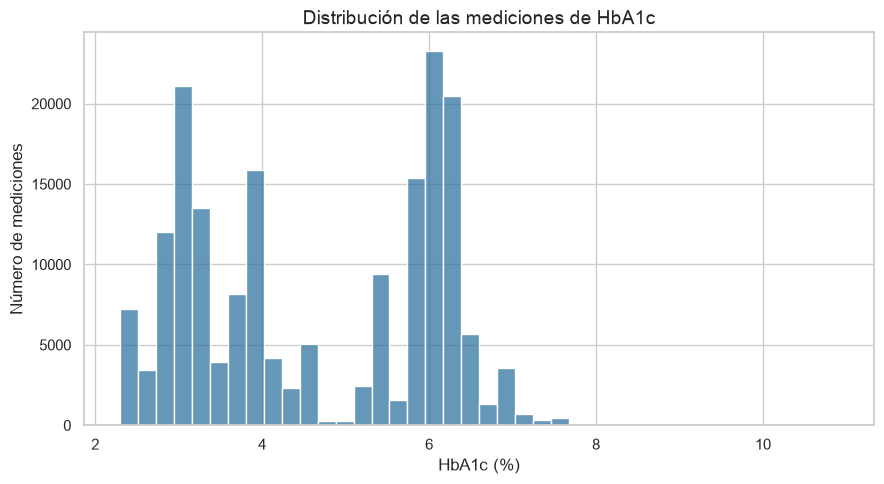

In [103]:
#Visualizar la distribución
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(
    figsize=(9, 5),
)

sns.histplot(
    data=hba1c,
    x="VALUE_NUMERIC",
    bins=40,
    color="#3274A1",
    edgecolor="white",
    ax=ax,
)

ax.set_title(
    "Distribución de las mediciones de HbA1c",
    fontsize=14,
)

ax.set_xlabel("HbA1c (%)")
ax.set_ylabel("Número de mediciones")

plt.tight_layout()
plt.show()

In [104]:
#Filtramos a los pacientes con al menos tres mediciones
conteo_hba1c_paciente = (
    hba1c.groupby(
        "PATIENT",
        observed=True,
    )
    .size()
    .rename("n_mediciones")
)

n_pacientes_con_hba1c = len(
    conteo_hba1c_paciente
)

n_pacientes_hba1c_3 = int(
    (conteo_hba1c_paciente >= 3).sum()
)

porcentaje_hba1c_3_con_medicion = (
    n_pacientes_hba1c_3
    / n_pacientes_con_hba1c
    * 100
)

porcentaje_hba1c_3_cohorte = (
    n_pacientes_hba1c_3
    / len(patients_opt)
    * 100
)

print(
    "Pacientes con al menos una HbA1c:",
    f"{n_pacientes_con_hba1c:,}",
)

print(
    "Pacientes con al menos tres mediciones:",
    f"{n_pacientes_hba1c_3:,}",
)

print(
    "Porcentaje entre pacientes con HbA1c:",
    f"{porcentaje_hba1c_3_con_medicion:.3f}%"
)

print(
    "Porcentaje respecto a la cohorte completa:",
    f"{porcentaje_hba1c_3_cohorte:.3f}%"
)


display(
    conteo_hba1c_paciente.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).to_frame()
)

Pacientes con al menos una HbA1c: 9,827
Pacientes con al menos tres mediciones: 8,836
Porcentaje entre pacientes con HbA1c: 89.916%
Porcentaje respecto a la cohorte completa: 38.407%


,n_mediciones
count,"9,827.000"
mean,18.518
std,36.384
min,1.000
25%,6.000
50%,10.000
75%,13.000
90%,36.000
95%,68.700
99%,196.740


In [105]:
#Media por paciente 
media_hba1c_por_paciente = (
    hba1c.groupby(
        "PATIENT",
        observed=True,
    )["VALUE_NUMERIC"]
    .mean()
)

resumen_hba1c_paciente = (
    media_hba1c_por_paciente
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .rename("media_HbA1c_por_paciente")
    .to_frame()
)

display(resumen_hba1c_paciente)

,media_HbA1c_por_paciente
count,"9,827.000"
mean,5.702
std,0.989
min,2.300
1%,2.882
5%,3.114
25%,5.900
50%,6.082
75%,6.150
95%,6.500


In [106]:
comparacion_medias_hba1c = pd.DataFrame(
    {
        "estimacion": [
            "Media global de todas las mediciones",
            "Media de las medias por paciente",
        ],
        "HbA1c_porcentaje": [
            hba1c["VALUE_NUMERIC"].mean(),
            media_hba1c_por_paciente.mean(),
        ],
        "ponderacion": [
            "Cada medición tiene el mismo peso",
            "Cada paciente tiene el mismo peso",
        ],
    }
)

display(comparacion_medias_hba1c)

,estimacion,HbA1c_porcentaje,ponderacion
0,Media global de todas las mediciones,4.630,Cada medición tiene el mismo peso
1,Media de las medias por paciente,5.702,Cada paciente tiene el mismo peso


**Nota:** La primera medida responde: ¿Cuál es el promedio de todas las mediciones registradas? y la segunda medición responde: ¿Cuál es el promedio del valor medio de cada paciente?

In [108]:
#6. Confirmar los diez códigos frecuentes
display(top10_codigos_observacion)

,CODE,DESCRIPTION,frecuencia,porcentaje_observaciones
0,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,584224,3.305
1,8480-6,Systolic Blood Pressure,332352,1.880
2,8462-4,Diastolic Blood Pressure,332352,1.880
3,29463-7,Body Weight,315939,1.787
4,9279-1,Respiratory rate,308985,1.748
5,8867-4,Heart rate,308985,1.748
6,8302-2,Body Height,302565,1.712
7,72166-2,Tobacco smoking status,301694,1.707
8,39156-5,Body mass index (BMI) [Ratio],280744,1.588
9,74006-8,Weight difference [Mass difference] --pre dial...,245248,1.387


### Resultados del análisis de HbA1c

Los códigos más frecuentes correspondieron principalmente a signos vitales, dolor y mediciones antropométricas. La presión arterial sistólica y diastólica presentaron la misma frecuencia, consistente con su registro conjunto.

Se identificaron 181,975 mediciones numéricas válidas de HbA1c en 9,827 pacientes. La mediana fue de 4.4% y el rango observado fue de 2.3% a 10.9%. Un total de 8,836 pacientes, equivalente al 89.92% de quienes tenían HbA1c y al 38.41% de la cohorte completa, presentó al menos tres mediciones.

La media global de todas las mediciones fue de 4.63%, mientras que la media de los promedios individuales fue de 5.70%. La diferencia indica que los pacientes no aportaron el mismo número de registros y que aquellos con mayor frecuencia de medición tuvieron, en conjunto, valores diferentes. Por ello, ambas estimaciones responden preguntas distintas y no deben interpretarse como equivalentes.

### 6. Formato ancho y valores implausibles

In [109]:
analitos_seleccionados = {
    "8480-6": "SBP",
    "8462-4": "DBP",
    "8867-4": "HEART_RATE",
    "9279-1": "RESPIRATORY_RATE",
    "39156-5": "BMI",
    "4548-4": "HBA1C",
}

In [110]:
columnas_formato_ancho = [
    "DATE",
    "PATIENT",
    "CODE",
    "VALUE",
    "UNITS",
    "TYPE",
]

bloques_analitos = []
filas_revisadas_ancho = 0

inicio_formato_ancho = time.perf_counter()

lector_formato_ancho = pd.read_csv(
    OBSERVATIONS_FILE,
    usecols=columnas_formato_ancho,
    dtype={
        "PATIENT": "string[pyarrow]",
        "CODE": "string[pyarrow]",
        "VALUE": "string[pyarrow]",
        "UNITS": "category",
        "TYPE": "category",
    },
    parse_dates=["DATE"],
    date_format="ISO8601",
    chunksize=500_000,
)

for numero_bloque, chunk in enumerate(
    lector_formato_ancho,
    start=1,
):
    filas_revisadas_ancho += len(chunk)

    es_analito_seleccionado = chunk["CODE"].isin(
        analitos_seleccionados
    )

    seleccion = chunk.loc[
        es_analito_seleccionado,
        [
            "DATE",
            "PATIENT",
            "CODE",
            "VALUE",
            "UNITS",
            "TYPE",
        ],
    ].copy()

    if not seleccion.empty:
        seleccion["ANALITO"] = (
            seleccion["CODE"]
            .map(analitos_seleccionados)
            .astype("string")
        )

        seleccion["VALUE_NUMERIC"] = pd.to_numeric(
            seleccion["VALUE"],
            errors="coerce",
        ).astype("float32")

        # Convertir el instante a día calendario UTC
        seleccion["FECHA"] = (
            seleccion["DATE"].dt.normalize()
        )

        bloques_analitos.append(
            seleccion[
                [
                    "PATIENT",
                    "FECHA",
                    "ANALITO",
                    "VALUE_NUMERIC",
                    "UNITS",
                ]
            ]
        )

    print(
        f"Bloque {numero_bloque:02d} | "
        f"filas revisadas: "
        f"{filas_revisadas_ancho:,} | "
        f"filas seleccionadas: "
        f"{sum(len(x) for x in bloques_analitos):,}"
    )

    del (
        chunk,
        seleccion,
        es_analito_seleccionado,
    )
    gc.collect()

tiempo_extraccion_ancho = (
    time.perf_counter() - inicio_formato_ancho
)

Bloque 01 | filas revisadas: 500,000 | filas seleccionadas: 48,663
Bloque 02 | filas revisadas: 1,000,000 | filas seleccionadas: 98,935
Bloque 03 | filas revisadas: 1,500,000 | filas seleccionadas: 145,376
Bloque 04 | filas revisadas: 2,000,000 | filas seleccionadas: 193,931
Bloque 05 | filas revisadas: 2,500,000 | filas seleccionadas: 244,955
Bloque 06 | filas revisadas: 3,000,000 | filas seleccionadas: 291,396
Bloque 07 | filas revisadas: 3,500,000 | filas seleccionadas: 338,868
Bloque 08 | filas revisadas: 4,000,000 | filas seleccionadas: 389,447
Bloque 09 | filas revisadas: 4,500,000 | filas seleccionadas: 440,547
Bloque 10 | filas revisadas: 5,000,000 | filas seleccionadas: 492,418
Bloque 11 | filas revisadas: 5,500,000 | filas seleccionadas: 540,966
Bloque 12 | filas revisadas: 6,000,000 | filas seleccionadas: 588,095
Bloque 13 | filas revisadas: 6,500,000 | filas seleccionadas: 638,278
Bloque 14 | filas revisadas: 7,000,000 | filas seleccionadas: 692,906
Bloque 15 | filas revisa

In [111]:
observaciones_analitos = pd.concat(
    bloques_analitos,
    ignore_index=True,
)

del bloques_analitos
gc.collect()

print(
    f"Observaciones seleccionadas: "
    f"{len(observaciones_analitos):,}"
)

print(
    f"Tiempo de extracción: "
    f"{tiempo_extraccion_ancho:,.3f} s"
)

print(
    f"Memoria utilizada: "
    f"{bytes_a_mb(observaciones_analitos.memory_usage(deep=True).sum()):,.3f} MiB"
)

Observaciones seleccionadas: 1,745,393
Tiempo de extracción: 29.266 s
Memoria utilizada: 275.454 MiB


In [112]:
tabla_unidades_analitos = (
    observaciones_analitos.groupby(
        ["ANALITO", "UNITS"],
        observed=True,
        dropna=False,
    )
    .size()
    .rename("frecuencia")
    .reset_index()
)

display(tabla_unidades_analitos)

,ANALITO,UNITS,frecuencia
0,BMI,kg/m2,280744
1,DBP,mm[Hg],332352
2,HBA1C,%,181975
3,HEART_RATE,/min,308985
4,RESPIRATORY_RATE,/min,308985
5,SBP,mm[Hg],332352


In [113]:
#Auditar resultados antes del pivote
conteo_por_paciente_fecha_analito = (
    observaciones_analitos.groupby(
        [
            "PATIENT",
            "FECHA",
            "ANALITO",
        ],
        observed=True,
    )
    .size()
    .rename("n_mediciones")
)

grupos_duplicados_pivote = (
    conteo_por_paciente_fecha_analito.loc[
        conteo_por_paciente_fecha_analito > 1
    ]
)

print(
    "Combinaciones paciente–fecha–analito:",
    f"{len(conteo_por_paciente_fecha_analito):,}",
)

print(
    "Combinaciones con más de una medición:",
    f"{len(grupos_duplicados_pivote):,}",
)

print(
    "Máximo de mediciones en una combinación:",
    f"{conteo_por_paciente_fecha_analito.max():,}",
)

display(
    grupos_duplicados_pivote.describe().to_frame()
)

Combinaciones paciente–fecha–analito: 1,743,453
Combinaciones con más de una medición: 1,940
Máximo de mediciones en una combinación: 2


,n_mediciones
count,"1,940.000"
mean,2.000
std,0.000
min,2.000
25%,2.000
50%,2.000
75%,2.000
max,2.000


In [114]:
display(
    grupos_duplicados_pivote.sort_values(
        ascending=False
    ).head(20)
)

PATIENT                               FECHA                      ANALITO         
009e3d98-ff95-46b1-7de3-e6ddbaf114fd  2009-12-01 00:00:00+00:00  HBA1C               2
a5c04554-122c-60ab-939d-016bee14f38d  2020-08-21 00:00:00+00:00  HEART_RATE          2
a88a9bcb-c3a9-d733-9614-1ea9ec42b8cd  2021-01-19 00:00:00+00:00  HEART_RATE          2
                                                                 DBP                 2
a865b004-4a0d-ba29-0f89-fe0188ff32dc  2025-11-05 00:00:00+00:00  HBA1C               2
a8193557-4558-eedb-9977-0344ae53563c  2021-01-23 00:00:00+00:00  SBP                 2
                                                                 RESPIRATORY_RATE    2
                                                                 HEART_RATE          2
                                                                 DBP                 2
a8188580-c1e2-c8a2-225c-4aa32f0186e9  2020-10-23 00:00:00+00:00  SBP                 2
                                                

In [115]:
observaciones_wide = (
    observaciones_analitos.pivot_table(
        index=[
            "PATIENT",
            "FECHA",
        ],
        columns="ANALITO",
        values="VALUE_NUMERIC",
        aggfunc="median",
        observed=True,
    )
    .reset_index()
)

observaciones_wide.columns.name = None

print(
    f"Dimensiones del formato ancho: "
    f"{observaciones_wide.shape}"
)

print(
    f"Memoria del formato ancho: "
    f"{bytes_a_mb(observaciones_wide.memory_usage(deep=True).sum()):,.3f} MiB"
)

display(observaciones_wide.head())

Dimensiones del formato ancho: (370321, 8)
Memoria del formato ancho: 26.885 MiB


,PATIENT,FECHA,BMI,DBP,HBA1C,HEART_RATE,RESPIRATORY_RATE,SBP
0,0000f9aa-864a-7086-d0f9-62e3d70f47cc,2016-12-17 00:00:00+00:00,22.600,84.000,NaN,94.000,15.000,117.000
1,0000f9aa-864a-7086-d0f9-62e3d70f47cc,2018-08-11 00:00:00+00:00,23.400,83.000,NaN,77.000,14.000,124.000
2,0000f9aa-864a-7086-d0f9-62e3d70f47cc,2021-08-14 00:00:00+00:00,24.700,77.000,NaN,82.000,15.000,127.000
3,0000f9aa-864a-7086-d0f9-62e3d70f47cc,2022-04-30 00:00:00+00:00,24.700,77.000,NaN,71.000,13.000,128.000
4,0000f9aa-864a-7086-d0f9-62e3d70f47cc,2024-08-17 00:00:00+00:00,26.000,84.000,NaN,75.000,16.000,129.000


In [117]:
assert not observaciones_wide.duplicated(
    subset=["PATIENT", "FECHA"]
).any()

assert len(observaciones_wide) <= len(
    observaciones_analitos
)

print(
    "Cada fila representa una combinación única "
    "de paciente y fecha."
)

Cada fila representa una combinación única de paciente y fecha.


Se encontraron 1,940 combinaciones paciente–fecha–analito con dos mediciones. Como `pivot_table` agregaría estas filas automáticamente, las duplicidades se cuantificaron antes del pivote. Se empleó la mediana para producir un único valor diario. Esta transformación redujo la memoria de 275.45 a 26.89 MiB, aunque implica perder la variabilidad intradía.

In [118]:
rangos_validacion = {
    "SBP": {
        "minimo": 60,
        "maximo": 240,
        "tipo": "Rango fisiológico operativo",
    },
    "DBP": {
        "minimo": 20,
        "maximo": 150,
        "tipo": "Rango fisiológico operativo",
    },
    "HEART_RATE": {
        "minimo": 20,
        "maximo": 250,
        "tipo": "Rango fisiológico operativo",
    },
    "RESPIRATORY_RATE": {
        "minimo": 4,
        "maximo": 45,
        "tipo": "Rango fisiológico operativo",
    },
    "BMI": {
        "minimo": 12,
        "maximo": 90,
        "tipo": "Rango de validez para EHR",
    },
    "HBA1C": {
        "minimo": 3.4,
        "maximo": 20,
        "tipo": "Rango analítico reportable",
    },
}

In [120]:
#Detectar valores fuera de rango
flags_implausibles = pd.DataFrame(
    index=observaciones_wide.index
)

resultados_rangos = []

for analito, regla in rangos_validacion.items():
    valores = observaciones_wide[analito]

    disponible = valores.notna()

    fuera_rango = (
        disponible
        & (
            (valores < regla["minimo"])
            | (valores > regla["maximo"])
        )
    )

    flags_implausibles[
        f"{analito}_FUERA_RANGO"
    ] = fuera_rango

    resultados_rangos.append(
        {
            "analito": analito,
            "tipo_regla": regla["tipo"],
            "minimo_aceptado": regla["minimo"],
            "maximo_aceptado": regla["maximo"],
            "n_disponibles": int(disponible.sum()),
            "n_fuera_rango": int(fuera_rango.sum()),
            "porcentaje_fuera_rango": (
                fuera_rango.sum()
                / disponible.sum()
                * 100
                if disponible.sum() > 0
                else np.nan
            ),
            "minimo_observado": valores.min(),
            "maximo_observado": valores.max(),
        }
    )

tabla_valores_implausibles = pd.DataFrame(
    resultados_rangos
)

display(tabla_valores_implausibles)

,analito,tipo_regla,minimo_aceptado,maximo_aceptado,n_disponibles,n_fuera_rango,porcentaje_fuera_rango,minimo_observado,maximo_observado
0,SBP,Rango fisiológico operativo,60.000,240,331988,793,0.239,25.000,182.000
1,DBP,Rango fisiológico operativo,20.000,150,331988,23,0.007,11.000,136.000
2,HEART_RATE,Rango fisiológico operativo,20.000,250,308622,0,0.000,50.000,200.000
3,RESPIRATORY_RATE,Rango fisiológico operativo,4.000,45,308622,0,0.000,12.000,40.000
4,BMI,Rango de validez para EHR,12.000,90,280744,0,0.000,12.300,54.100
5,HBA1C,Rango analítico reportable,3.400,20,181489,57164,31.497,2.300,10.900


In [121]:
#Coherencia entre SBP y DBP
presiones_completas = (
    observaciones_wide["SBP"].notna()
    & observaciones_wide["DBP"].notna()
)

presion_incoherente = (
    presiones_completas
    & (
        observaciones_wide["SBP"]
        <= observaciones_wide["DBP"]
    )
)

flags_implausibles[
    "SBP_MENOR_IGUAL_DBP"
] = presion_incoherente

print(
    "Pares completos SBP–DBP:",
    f"{presiones_completas.sum():,}",
)

print(
    "Pares con SBP ≤ DBP:",
    f"{presion_incoherente.sum():,}",
)

print(
    "Porcentaje de pares incoherentes:",
    f"{presion_incoherente.sum() / presiones_completas.sum() * 100:.3f}%"
)

Pares completos SBP–DBP: 331,988
Pares con SBP ≤ DBP: 501
Porcentaje de pares incoherentes: 0.151%


In [122]:
fila_con_algun_problema = (
    flags_implausibles.any(axis=1)
)

print(
    "Filas con al menos un valor marcado:",
    f"{fila_con_algun_problema.sum():,}",
)

print(
    "Porcentaje del formato ancho:",
    f"{fila_con_algun_problema.mean() * 100:.3f}%"
)

Filas con al menos un valor marcado: 58,295
Porcentaje del formato ancho: 15.742%


In [124]:
#Ejemplo de muestras
columnas_flags = flags_implausibles.columns[
    flags_implausibles.any(axis=0)
]

ejemplos_implausibles = pd.concat(
    [
        observaciones_wide.loc[
            fila_con_algun_problema
        ],
        flags_implausibles.loc[
            fila_con_algun_problema,
            columnas_flags,
        ],
    ],
    axis=1,
).head(30)

display(ejemplos_implausibles)

,PATIENT,FECHA,BMI,DBP,HBA1C,HEART_RATE,RESPIRATORY_RATE,SBP,SBP_FUERA_RANGO,DBP_FUERA_RANGO,HBA1C_FUERA_RANGO,SBP_MENOR_IGUAL_DBP
105,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-03-12 00:00:00+00:00,27.500,72.000,3.000,90.000,13.000,115.000,False,False,True,False
106,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-04-09 00:00:00+00:00,27.500,76.000,3.000,74.000,12.000,114.000,False,False,True,False
107,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-05-07 00:00:00+00:00,27.500,80.000,2.900,69.000,13.000,116.000,False,False,True,False
108,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-06-04 00:00:00+00:00,27.500,70.000,3.100,93.000,15.000,114.000,False,False,True,False
109,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-07-09 00:00:00+00:00,27.500,68.000,3.100,81.000,13.000,120.000,False,False,True,False
112,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-10-08 00:00:00+00:00,27.500,70.000,3.200,72.000,14.000,119.000,False,False,True,False
113,003a75ed-0487-cd89-5403-4659d3d3e5ef,2009-12-03 00:00:00+00:00,27.500,72.000,3.100,87.000,14.000,123.000,False,False,True,False
114,003a75ed-0487-cd89-5403-4659d3d3e5ef,2010-01-21 00:00:00+00:00,27.500,69.000,3.100,67.000,14.000,128.000,False,False,True,False
115,003a75ed-0487-cd89-5403-4659d3d3e5ef,2010-02-18 00:00:00+00:00,27.500,73.000,3.100,92.000,14.000,133.000,False,False,True,False
116,003a75ed-0487-cd89-5403-4659d3d3e5ef,2010-03-11 00:00:00+00:00,27.500,69.000,2.900,62.000,12.000,116.000,False,False,True,False


In [125]:
#Creamos una versión analítica sin sobrescribir los datos
observaciones_wide_limpias = (
    observaciones_wide.copy()
)

for analito in rangos_validacion:
    mascara = flags_implausibles[
        f"{analito}_FUERA_RANGO"
    ]

    observaciones_wide_limpias.loc[
        mascara,
        analito,
    ] = np.nan

In [126]:
observaciones_wide_limpias.loc[
    presion_incoherente,
    ["SBP", "DBP"],
] = np.nan

In [128]:
print(
    "Mismas dimensiones:",
    observaciones_wide.shape
    == observaciones_wide_limpias.shape,
)

print(
    "Mismo índice:",
    observaciones_wide.index.equals(
        observaciones_wide_limpias.index
    ),
)

print(
    "PATIENT idéntico:",
    observaciones_wide["PATIENT"].equals(
        observaciones_wide_limpias["PATIENT"]
    ),
)

print(
    "FECHA idéntica:",
    observaciones_wide["FECHA"].equals(
        observaciones_wide_limpias["FECHA"]
    ),
)

print("\nTipos originales:")
print(
    observaciones_wide[
        ["PATIENT", "FECHA"]
    ].dtypes
)

print("\nTipos después de la limpieza:")
print(
    observaciones_wide_limpias[
        ["PATIENT", "FECHA"]
    ].dtypes
)

Mismas dimensiones: True
Mismo índice: True
PATIENT idéntico: True
FECHA idéntica: True

Tipos originales:
PATIENT        string[pyarrow]
FECHA      datetime64[ns, UTC]
dtype: object

Tipos después de la limpieza:
PATIENT        string[pyarrow]
FECHA      datetime64[ns, UTC]
dtype: object


In [130]:
assert (
    observaciones_wide.shape
    == observaciones_wide_limpias.shape
)

assert observaciones_wide.index.equals(
    observaciones_wide_limpias.index
)

pd.testing.assert_series_equal(
    observaciones_wide["PATIENT"],
    observaciones_wide_limpias["PATIENT"],
    check_dtype=False,
    check_names=False,
)

pd.testing.assert_series_equal(
    observaciones_wide["FECHA"],
    observaciones_wide_limpias["FECHA"],
    check_dtype=False,
    check_names=False,
)

print(
    "La versión original fue preservada y la "
    "versión analítica conserva las mismas filas, "
    "pacientes y fechas."
)

La versión original fue preservada y la versión analítica conserva las mismas filas, pacientes y fechas.


In [131]:
display(tabla_valores_implausibles)

,analito,tipo_regla,minimo_aceptado,maximo_aceptado,n_disponibles,n_fuera_rango,porcentaje_fuera_rango,minimo_observado,maximo_observado
0,SBP,Rango fisiológico operativo,60.000,240,331988,793,0.239,25.000,182.000
1,DBP,Rango fisiológico operativo,20.000,150,331988,23,0.007,11.000,136.000
2,HEART_RATE,Rango fisiológico operativo,20.000,250,308622,0,0.000,50.000,200.000
3,RESPIRATORY_RATE,Rango fisiológico operativo,4.000,45,308622,0,0.000,12.000,40.000
4,BMI,Rango de validez para EHR,12.000,90,280744,0,0.000,12.300,54.100
5,HBA1C,Rango analítico reportable,3.400,20,181489,57164,31.497,2.300,10.900


### Valores fuera de los rangos de validación

Se marcaron 58,295 filas del formato ancho (15.74%) con al menos una observación fuera de los criterios adoptados. La mayor contribución provino de HbA1c: 57,164 de 181,489 valores diarios (31.50%) estuvieron por debajo del rango analítico reportable de 3.4%. Estos valores no se interpretaron automáticamente como fisiológicamente imposibles, sino como incompatibles con el intervalo analítico seleccionado y candidatos a verificación.

En los signos vitales se identificaron 793 valores sistólicos y 23 diastólicos fuera de los rangos operativos. Además, 501 de 331,988 pares completos (0.151%) presentaron presión sistólica menor o igual que la diastólica. No se detectaron valores fuera de rango en frecuencia cardiaca, frecuencia respiratoria o BMI.

Los datos originales fueron conservados. En la copia analítica, los valores marcados se sustituyeron por faltantes para evitar que influyeran en análisis posteriores. En un conjunto clínico real se revisarían primero las unidades, el método analítico y el registro fuente.

### 7. Procesamiento bajo un presupuesto de memoria

In [132]:
%%writefile actividad7_chunks.py

import argparse
import json
import threading
import time
from pathlib import Path

import pandas as pd
import psutil


def bytes_a_mib(numero_bytes):
    return numero_bytes / (1024 ** 2)


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--input", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--metrics", required=True)
    parser.add_argument("--chunksize", type=int, default=100_000)
    parser.add_argument("--budget-mib", type=float, default=200)

    args = parser.parse_args()

    input_path = Path(args.input)
    output_path = Path(args.output)
    metrics_path = Path(args.metrics)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    metrics_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    process = psutil.Process()

    baseline_bytes = process.memory_info().rss
    peak_bytes = baseline_bytes

    stop_monitor = threading.Event()

    def monitor_memory():
        nonlocal peak_bytes

        while not stop_monitor.is_set():
            current_bytes = process.memory_info().rss
            peak_bytes = max(
                peak_bytes,
                current_bytes,
            )
            time.sleep(0.01)

    monitor_thread = threading.Thread(
        target=monitor_memory,
        daemon=True,
    )

    monitor_thread.start()

    acumulado = None
    total_filas = 0
    total_bloques = 0

    inicio = time.perf_counter()

    lector = pd.read_csv(
        input_path,
        usecols=["CODE", "VALUE"],
        dtype={
            "CODE": "string[pyarrow]",
            "VALUE": "string[pyarrow]",
        },
        chunksize=args.chunksize,
    )

    for numero_bloque, chunk in enumerate(
        lector,
        start=1,
    ):
        value_numeric = pd.to_numeric(
            chunk["VALUE"],
            errors="coerce",
        ).astype("float32")

        datos_numericos = pd.DataFrame(
            {
                "CODE": chunk["CODE"],
                "VALUE_NUMERIC": value_numeric,
            }
        )

        grupo = datos_numericos.groupby(
            "CODE",
            observed=True,
        )

        resumen_bloque = grupo[
            "VALUE_NUMERIC"
        ].agg(
            n_numeric="count",
            suma_numeric="sum",
        )

        resumen_bloque["n_total"] = grupo.size()

        if acumulado is None:
            acumulado = resumen_bloque.copy()
        else:
            acumulado = acumulado.add(
                resumen_bloque,
                fill_value=0,
            )

        total_filas += len(chunk)
        total_bloques = numero_bloque

        if numero_bloque % 20 == 0:
            print(
                f"Bloque {numero_bloque:03d} | "
                f"filas: {total_filas:,}",
                flush=True,
            )

        del (
            chunk,
            value_numeric,
            datos_numericos,
            grupo,
            resumen_bloque,
        )

    tiempo_s = time.perf_counter() - inicio

    resultado = acumulado.reset_index()

    resultado["n_total"] = (
        resultado["n_total"].astype("int64")
    )

    resultado["n_numeric"] = (
        resultado["n_numeric"].astype("int64")
    )

    resultado["media_numeric"] = (
        resultado["suma_numeric"]
        / resultado["n_numeric"].where(
            resultado["n_numeric"] > 0
        )
    )

    resultado = resultado.sort_values(
        "n_total",
        ascending=False,
    )

    resultado.to_csv(
        output_path,
        index=False,
    )

    stop_monitor.set()
    monitor_thread.join()

    peak_mib = bytes_a_mib(peak_bytes)
    baseline_mib = bytes_a_mib(baseline_bytes)

    metricas = {
        "filas_procesadas": total_filas,
        "bloques_procesados": total_bloques,
        "chunksize": args.chunksize,
        "tiempo_s": tiempo_s,
        "memoria_inicial_mib": baseline_mib,
        "memoria_pico_mib": peak_mib,
        "incremento_pico_mib": (
            peak_mib - baseline_mib
        ),
        "presupuesto_mib": args.budget_mib,
        "cumple_presupuesto_absoluto": (
            peak_mib <= args.budget_mib
        ),
    }

    metrics_path.write_text(
        json.dumps(
            metricas,
            indent=2,
        ),
        encoding="utf-8",
    )

    print(
        json.dumps(
            metricas,
            indent=2,
        ),
        flush=True,
    )


if __name__ == "__main__":
    main()

Writing actividad7_chunks.py


In [133]:
#Ejecutamos como proceso aislado
import subprocess
import sys

comando_actividad7 = [
    sys.executable,
    "actividad7_chunks.py",
    "--input",
    str(OBSERVATIONS_FILE),
    "--output",
    "results/actividad7_media_conteo_por_codigo.csv",
    "--metrics",
    "results/actividad7_metricas.json",
    "--chunksize",
    "100000",
    "--budget-mib",
    "200",
]

proceso_actividad7 = subprocess.run(
    comando_actividad7,
    capture_output=True,
    text=True,
)

print(proceso_actividad7.stdout)

if proceso_actividad7.stderr:
    print("Mensajes de error:")
    print(proceso_actividad7.stderr)

print(
    "Código de salida:",
    proceso_actividad7.returncode,
)

Bloque 020 | filas: 2,000,000
Bloque 040 | filas: 4,000,000
Bloque 060 | filas: 6,000,000
Bloque 080 | filas: 8,000,000
Bloque 100 | filas: 10,000,000
Bloque 120 | filas: 12,000,000
Bloque 140 | filas: 14,000,000
Bloque 160 | filas: 16,000,000
{
  "filas_procesadas": 17677231,
  "bloques_procesados": 177,
  "chunksize": 100000,
  "tiempo_s": 15.896266083000228,
  "memoria_inicial_mib": 103.96875,
  "memoria_pico_mib": 272.078125,
  "incremento_pico_mib": 168.109375,
  "presupuesto_mib": 200.0,
  "cumple_presupuesto_absoluto": false
}

Código de salida: 0


In [134]:
import json

with open(
    "results/actividad7_metricas.json",
    encoding="utf-8",
) as archivo:
    metricas_actividad7 = json.load(archivo)

display(
    pd.DataFrame(
        metricas_actividad7.items(),
        columns=["metrica", "valor"],
    )
)

,metrica,valor
0,filas_procesadas,17677231
1,bloques_procesados,177
2,chunksize,100000
3,tiempo_s,15.896
4,memoria_inicial_mib,103.969
5,memoria_pico_mib,272.078
6,incremento_pico_mib,168.109
7,presupuesto_mib,200.000
8,cumple_presupuesto_absoluto,False


In [135]:
resultado_actividad7 = pd.read_csv(
    "results/actividad7_media_conteo_por_codigo.csv",
    dtype={"CODE": "string[pyarrow]"},
)

assert (
    resultado_actividad7["n_total"].sum()
    == 17_677_231
)

assert (
    metricas_actividad7["filas_procesadas"]
    == 17_677_231
)

display(resultado_actividad7.head(20))

,CODE,n_numeric,suma_numeric,n_total,media_numeric
0,72514-3,584224,"1,835,333.000",584224,3.141
1,8480-6,332352,"38,832,124.000",332352,116.840
2,8462-4,332352,"26,098,020.000",332352,78.525
3,29463-7,315939,"22,189,290.000",315939,70.233
4,9279-1,308985,"4,402,837.000",308985,14.249
5,8867-4,308985,"25,009,576.000",308985,80.941
6,8302-2,302565,"47,516,390.000",302565,157.045
7,72166-2,0,0.000,301694,NaN
8,39156-5,280744,"7,503,077.500",280744,26.726
9,74006-8,245248,"735,552.440",245248,2.999


In [136]:
metricas_intento_100k = (
    metricas_actividad7.copy()
)

In [137]:
from pathlib import Path

ruta_script = Path(
    "actividad7_chunks.py"
)

contenido_script = ruta_script.read_text(
    encoding="utf-8"
)

contenido_script = contenido_script.replace(
    '"CODE": "string[pyarrow]",',
    '"CODE": "string",',
)

contenido_script = contenido_script.replace(
    '"VALUE": "string[pyarrow]",',
    '"VALUE": "string",',
)

contenido_script = contenido_script.replace(
    '.astype("float32")',
    '.astype("float64")',
)

ruta_script.write_text(
    contenido_script,
    encoding="utf-8",
)

print(
    "El programa fue actualizado para reducir "
    "la sobrecarga de memoria."
)

El programa fue actualizado para reducir la sobrecarga de memoria.


In [138]:
contenido_actualizado = ruta_script.read_text(
    encoding="utf-8"
)

assert 'string[pyarrow]' not in contenido_actualizado
assert '.astype("float32")' not in contenido_actualizado

print("Modificaciones verificadas.")

Modificaciones verificadas.


In [139]:
comando_actividad7_50k = [
    sys.executable,
    "actividad7_chunks.py",
    "--input",
    str(OBSERVATIONS_FILE),
    "--output",
    "results/actividad7_resultados_50000.csv",
    "--metrics",
    "results/actividad7_metricas_50000.json",
    "--chunksize",
    "50000",
    "--budget-mib",
    "200",
]

proceso_actividad7_50k = subprocess.run(
    comando_actividad7_50k,
    capture_output=True,
    text=True,
)

print(proceso_actividad7_50k.stdout)

if proceso_actividad7_50k.stderr:
    print("Mensajes de error:")
    print(proceso_actividad7_50k.stderr)

print(
    "Código de salida:",
    proceso_actividad7_50k.returncode,
)

Bloque 020 | filas: 1,000,000
Bloque 040 | filas: 2,000,000
Bloque 060 | filas: 3,000,000
Bloque 080 | filas: 4,000,000
Bloque 100 | filas: 5,000,000
Bloque 120 | filas: 6,000,000
Bloque 140 | filas: 7,000,000
Bloque 160 | filas: 8,000,000
Bloque 180 | filas: 9,000,000
Bloque 200 | filas: 10,000,000
Bloque 220 | filas: 11,000,000
Bloque 240 | filas: 12,000,000
Bloque 260 | filas: 13,000,000
Bloque 280 | filas: 14,000,000
Bloque 300 | filas: 15,000,000
Bloque 320 | filas: 16,000,000
Bloque 340 | filas: 17,000,000
{
  "filas_procesadas": 17677231,
  "bloques_procesados": 354,
  "chunksize": 50000,
  "tiempo_s": 16.327187916002003,
  "memoria_inicial_mib": 105.71875,
  "memoria_pico_mib": 275.640625,
  "incremento_pico_mib": 169.921875,
  "presupuesto_mib": 200.0,
  "cumple_presupuesto_absoluto": false
}

Código de salida: 0


In [140]:
with open(
    "results/actividad7_metricas_50000.json",
    encoding="utf-8",
) as archivo:
    metricas_intento_50k = json.load(archivo)

comparacion_intentos_actividad7 = pd.DataFrame(
    [
        {
            "intento": "100,000 filas",
            **metricas_intento_100k,
        },
        {
            "intento": "50,000 filas",
            **metricas_intento_50k,
        },
    ]
)

display(comparacion_intentos_actividad7)

,intento,filas_procesadas,bloques_procesados,chunksize,tiempo_s,memoria_inicial_mib,memoria_pico_mib,incremento_pico_mib,presupuesto_mib,cumple_presupuesto_absoluto
0,"100,000 filas",17677231,177,100000,15.896,103.969,272.078,168.109,200.000,False
1,"50,000 filas",17677231,354,50000,16.327,105.719,275.641,169.922,200.000,False


In [141]:
resultado_actividad7_50k = pd.read_csv(
    "results/actividad7_resultados_50000.csv",
    dtype={"CODE": "string"},
)

assert (
    resultado_actividad7_50k["n_total"].sum()
    == 17_677_231
)

assert (
    metricas_intento_50k["filas_procesadas"]
    == 17_677_231
)

print(
    "Cumple presupuesto absoluto:",
    metricas_intento_50k[
        "cumple_presupuesto_absoluto"
    ],
)

Cumple presupuesto absoluto: False


In [142]:
comparacion_resultados_chunks = (
    resultado_actividad7[
        [
            "CODE",
            "n_total",
            "n_numeric",
            "media_numeric",
        ]
    ]
    .merge(
        resultado_actividad7_50k[
            [
                "CODE",
                "n_total",
                "n_numeric",
                "media_numeric",
            ]
        ],
        on="CODE",
        how="outer",
        validate="one_to_one",
        suffixes=("_100k", "_50k"),
        indicator=True,
    )
)

assert (
    comparacion_resultados_chunks["_merge"]
    == "both"
).all()

assert (
    comparacion_resultados_chunks[
        "n_total_100k"
    ]
    == comparacion_resultados_chunks[
        "n_total_50k"
    ]
).all()

assert (
    comparacion_resultados_chunks[
        "n_numeric_100k"
    ]
    == comparacion_resultados_chunks[
        "n_numeric_50k"
    ]
).all()

medias_coinciden = np.allclose(
    comparacion_resultados_chunks[
        "media_numeric_100k"
    ],
    comparacion_resultados_chunks[
        "media_numeric_50k"
    ],
    equal_nan=True,
    rtol=1e-5,
    atol=1e-6,
)

assert medias_coinciden

print(
    "Los dos tamaños de bloque produjeron "
    "los mismos conteos y medias."
)

Los dos tamaños de bloque produjeron los mismos conteos y medias.


In [145]:
%%writefile actividad7_streaming.py

UsageError: %%writefile is a cell magic, but the cell body is empty.


In [147]:
%%writefile actividad7_streaming.py
import argparse
import csv
import json
import math
import threading
import time
from collections import defaultdict
from pathlib import Path

import psutil


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--archivo", required=True)
    parser.add_argument("--presupuesto-mib", type=float, default=200.0)
    parser.add_argument(
        "--salida-resultados",
        default="results/actividad7_resultados_streaming.csv",
    )
    parser.add_argument(
        "--salida-metricas",
        default="results/actividad7_metricas_streaming.json",
    )
    args = parser.parse_args()

    archivo = Path(args.archivo)
    salida_resultados = Path(args.salida_resultados)
    salida_metricas = Path(args.salida_metricas)

    salida_resultados.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    salida_metricas.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    proceso = psutil.Process()
    memoria_inicial = proceso.memory_info().rss
    memoria_pico = memoria_inicial
    detener_monitor = threading.Event()

    def monitor_memoria():
        nonlocal memoria_pico

        while not detener_monitor.is_set():
            memoria_actual = proceso.memory_info().rss
            memoria_pico = max(
                memoria_pico,
                memoria_actual,
            )
            detener_monitor.wait(0.01)

    monitor = threading.Thread(
        target=monitor_memoria,
        daemon=True,
    )
    monitor.start()

    n_total = defaultdict(int)
    n_numeric = defaultdict(int)
    suma_numeric = defaultdict(float)

    filas_procesadas = 0
    inicio = time.perf_counter()

    try:
        with archivo.open(
            mode="r",
            encoding="utf-8",
            newline="",
        ) as archivo_csv:

            lector = csv.reader(archivo_csv)
            encabezado = next(lector)

            indice_code = encabezado.index("CODE")
            indice_value = encabezado.index("VALUE")

            for fila in lector:
                codigo = fila[indice_code]
                valor = fila[indice_value]

                n_total[codigo] += 1
                filas_procesadas += 1

                if valor != "":
                    try:
                        valor_numerico = float(valor)

                        if math.isfinite(valor_numerico):
                            n_numeric[codigo] += 1
                            suma_numeric[codigo] += valor_numerico

                    except ValueError:
                        pass

                if filas_procesadas % 2_000_000 == 0:
                    print(
                        "Filas procesadas:",
                        f"{filas_procesadas:,}",
                        flush=True,
                    )

    finally:
        detener_monitor.set()
        monitor.join()

    tiempo_total = time.perf_counter() - inicio

    memoria_inicial_mib = memoria_inicial / (1024 ** 2)
    memoria_pico_mib = memoria_pico / (1024 ** 2)
    incremento_pico_mib = (
        memoria_pico - memoria_inicial
    ) / (1024 ** 2)

    with salida_resultados.open(
        mode="w",
        encoding="utf-8",
        newline="",
    ) as archivo_salida:

        columnas = [
            "CODE",
            "n_numeric",
            "suma_numeric",
            "n_total",
            "media_numeric",
        ]

        escritor = csv.DictWriter(
            archivo_salida,
            fieldnames=columnas,
        )
        escritor.writeheader()

        for codigo in sorted(n_total):
            cantidad_numerica = n_numeric[codigo]
            suma = suma_numeric[codigo]

            media = (
                suma / cantidad_numerica
                if cantidad_numerica > 0
                else ""
            )

            escritor.writerow(
                {
                    "CODE": codigo,
                    "n_numeric": cantidad_numerica,
                    "suma_numeric": suma,
                    "n_total": n_total[codigo],
                    "media_numeric": media,
                }
            )

    metricas = {
        "filas_procesadas": filas_procesadas,
        "metodo": "csv.reader fila por fila",
        "tiempo_s": tiempo_total,
        "memoria_inicial_mib": memoria_inicial_mib,
        "memoria_pico_mib": memoria_pico_mib,
        "incremento_pico_mib": incremento_pico_mib,
        "presupuesto_mib": args.presupuesto_mib,
        "cumple_presupuesto_absoluto": (
            memoria_pico_mib <= args.presupuesto_mib
        ),
    }

    with salida_metricas.open(
        mode="w",
        encoding="utf-8",
    ) as archivo_metricas:
        json.dump(
            metricas,
            archivo_metricas,
            indent=2,
            ensure_ascii=False,
        )

    print(json.dumps(
        metricas,
        indent=2,
        ensure_ascii=False,
    ))


if __name__ == "__main__":
    main()

Overwriting actividad7_streaming.py


In [148]:
import subprocess
import sys

comando_streaming = [
    sys.executable,
    "actividad7_streaming.py",
    "--archivo",
    str(OBSERVATIONS_FILE),
    "--presupuesto-mib",
    "200",
]

resultado_proceso = subprocess.run(
    comando_streaming,
    text=True,
    capture_output=True,
)

print(resultado_proceso.stdout)

if resultado_proceso.stderr:
    print("Mensajes de error:")
    print(resultado_proceso.stderr)

print(
    "Código de salida:",
    resultado_proceso.returncode,
)

Filas procesadas: 2,000,000
Filas procesadas: 4,000,000
Filas procesadas: 6,000,000
Filas procesadas: 8,000,000
Filas procesadas: 10,000,000
Filas procesadas: 12,000,000
Filas procesadas: 14,000,000
Filas procesadas: 16,000,000
{
  "filas_procesadas": 17677231,
  "metodo": "csv.reader fila por fila",
  "tiempo_s": 29.22324049999588,
  "memoria_inicial_mib": 23.78125,
  "memoria_pico_mib": 24.046875,
  "incremento_pico_mib": 0.265625,
  "presupuesto_mib": 200.0,
  "cumple_presupuesto_absoluto": true
}

Código de salida: 0


In [149]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

RESULTADOS_DIR = Path("results")

with open(
    RESULTADOS_DIR / "actividad7_metricas_streaming.json",
    encoding="utf-8",
) as archivo:
    metricas_streaming = json.load(archivo)

resultado_streaming = pd.read_csv(
    RESULTADOS_DIR / "actividad7_resultados_streaming.csv",
    dtype={"CODE": "string"},
)

display(
    pd.DataFrame(
        {
            "metrica": metricas_streaming.keys(),
            "valor": metricas_streaming.values(),
        }
    )
)

display(
    resultado_streaming
    .sort_values(
        "n_total",
        ascending=False,
    )
    .head(20)
)

,metrica,valor
0,filas_procesadas,17677231
1,metodo,csv.reader fila por fila
2,tiempo_s,29.223
3,memoria_inicial_mib,23.781
4,memoria_pico_mib,24.047
5,incremento_pico_mib,0.266
6,presupuesto_mib,200.000
7,cumple_presupuesto_absoluto,True


,CODE,n_numeric,suma_numeric,n_total,media_numeric
196,72514-3,584224,"1,835,333.000",584224,3.141
238,8480-6,332352,"38,832,125.100",332352,116.840
236,8462-4,332352,"26,098,019.600",332352,78.525
69,29463-7,315939,"22,189,283.300",315939,70.233
265,9279-1,308985,"4,402,836.500",308985,14.249
252,8867-4,308985,"25,009,577.200",308985,80.941
233,8302-2,302565,"47,516,408.100",302565,157.045
195,72166-2,0,0.000,301694,NaN
96,39156-5,280744,"7,503,076.900",280744,26.726
200,74006-8,245248,"735,552.400",245248,2.999


In [150]:
comparacion_streaming = resultado_actividad7_50k.merge(
    resultado_streaming,
    on="CODE",
    how="outer",
    suffixes=("_pandas", "_streaming"),
    validate="one_to_one",
    indicator=True,
)

assert (
    comparacion_streaming["_merge"] == "both"
).all(), "Hay códigos que no aparecen en ambos métodos."

assert (
    comparacion_streaming["n_total_pandas"]
    == comparacion_streaming["n_total_streaming"]
).all(), "Los conteos totales no coinciden."

assert (
    comparacion_streaming["n_numeric_pandas"]
    == comparacion_streaming["n_numeric_streaming"]
).all(), "Los conteos numéricos no coinciden."

medias_coinciden = np.allclose(
    comparacion_streaming["media_numeric_pandas"],
    comparacion_streaming["media_numeric_streaming"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

assert medias_coinciden, "Las medias numéricas no coinciden."

assert (
    int(resultado_streaming["n_total"].sum())
    == 17_677_231
), "No se contabilizaron todas las filas."

assert metricas_streaming[
    "cumple_presupuesto_absoluto"
], "No se cumplió el presupuesto absoluto."

print("Validación superada.")
print(
    "Los métodos produjeron los mismos "
    "conteos y medias."
)
print(
    "Filas verificadas:",
    f"{int(resultado_streaming['n_total'].sum()):,}",
)
print(
    "Memoria pico:",
    f"{metricas_streaming['memoria_pico_mib']:.3f} MiB",
)

Validación superada.
Los métodos produjeron los mismos conteos y medias.
Filas verificadas: 17,677,231
Memoria pico: 24.047 MiB


### Resultado del procesamiento con presupuesto de memoria

El archivo `observations.csv`, compuesto por 17,677,231 registros, se
procesó mediante lectura secuencial con `csv.reader`. En cada iteración
se conservó únicamente la fila actual y se actualizaron acumuladores por
código clínico para obtener el número total de observaciones, el número
de valores numéricos, su suma y su media.

El proceso alcanzó un pico absoluto de 24.047 MiB, por debajo del
presupuesto establecido de 200 MiB. El incremento respecto a la memoria
inicial fue de solo 0.266 MiB. Por tanto, el método cumplió el presupuesto
de memoria sin depender de que el archivo completo cupiera en RAM.

Los resultados se compararon con los obtenidos mediante pandas por
bloques. Ambos métodos produjeron los mismos conteos y medias, lo que
demuestra que la reducción del consumo de memoria no alteró el resultado
analítico.

La lectura secuencial tardó 29.223 segundos, frente a aproximadamente
16 segundos con pandas por bloques. Esto representa un compromiso entre
memoria y velocidad: el streaming fue más lento, pero redujo el pico
absoluto de memoria de aproximadamente 275 MiB a 24 MiB. Además, disminuir
el tamaño de los bloques de pandas de 100,000 a 50,000 filas no redujo
su memoria pico, lo que indica que una parte importante del consumo
provenía del intérprete y del motor de lectura, no solamente del tamaño
del bloque.

### 8. Comparación del pipeline en pandas, Polars y PySpark

Se ejecutará el mismo pipeline analítico sobre `observations.csv` utilizando
pandas, Polars y PySpark. En los tres casos se leerán las columnas `CODE` y
`VALUE`, se intentará convertir `VALUE` a número y se calcularán por código
el número total de observaciones, el número de valores numéricos, la suma y
la media.

Cada implementación se ejecutará en un proceso independiente. Esto permite
medir su consumo de memoria sin mezclarlo con los objetos almacenados por el
kernel de Jupyter y garantiza que la memoria utilizada por un motor se libere
antes de ejecutar el siguiente.

In [152]:
#Función compacta para ejecutar y medir procesos
import json
import subprocess
import sys
import threading
import time
from pathlib import Path

import pandas as pd
import psutil

RESULTADOS_DIR = Path("results")
RESULTADOS_DIR.mkdir(exist_ok=True)

def ejecutar_motor(nombre, programa):
    proceso = subprocess.Popen(
        [sys.executable, "-c", programa],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    pico_bytes = 0
    inicio = time.perf_counter()

    while proceso.poll() is None:
        try:
            principal = psutil.Process(proceso.pid)
            procesos = [principal] + principal.children(recursive=True)

            memoria_actual = sum(
                p.memory_info().rss
                for p in procesos
                if p.is_running()
            )

            pico_bytes = max(pico_bytes, memoria_actual)

        except (psutil.NoSuchProcess, psutil.AccessDenied):
            pass

        time.sleep(0.02)

    stdout, stderr = proceso.communicate()
    tiempo = time.perf_counter() - inicio

    if proceso.returncode != 0:
        print(stderr)
        raise RuntimeError(
            f"El motor {nombre} terminó con código "
            f"{proceso.returncode}."
        )

    metricas = {
        "motor": nombre,
        "tiempo_s": tiempo,
        "memoria_pico_mib": pico_bytes / (1024 ** 2),
        "codigo_salida": proceso.returncode,
    }

    print(stdout)
    display(pd.DataFrame([metricas]))

    return metricas

In [153]:
#Pipeline con pandas
programa_pandas = f'''
import json
import time
import pandas as pd
from pathlib import Path

archivo = Path({str(OBSERVATIONS_FILE)!r})
salida = Path("results/actividad8_pandas.csv")
inicio = time.perf_counter()
acumulados = []

for bloque in pd.read_csv(
    archivo,
    usecols=["CODE", "VALUE"],
    dtype={{"CODE": "string", "VALUE": "string"}},
    chunksize=100_000,
):
    bloque["VALUE_NUM"] = pd.to_numeric(
        bloque["VALUE"],
        errors="coerce",
    )

    parcial = bloque.groupby(
        "CODE",
        observed=True,
    ).agg(
        n_total=("VALUE", "size"),
        n_numeric=("VALUE_NUM", "count"),
        suma_numeric=("VALUE_NUM", "sum"),
    )

    acumulados.append(parcial)

resultado = (
    pd.concat(acumulados)
    .groupby(level=0)
    .sum()
    .reset_index()
)

resultado["media_numeric"] = (
    resultado["suma_numeric"]
    / resultado["n_numeric"].replace(0, pd.NA)
)

resultado.to_csv(salida, index=False)

print(
    json.dumps(
        {{
            "motor": "pandas",
            "filas_procesadas": int(resultado["n_total"].sum()),
            "codigos": len(resultado),
            "tiempo_pipeline_s": time.perf_counter() - inicio,
        }},
        indent=2,
    )
)
'''

metricas_pandas = ejecutar_motor(
    "pandas",
    programa_pandas,
)

{
  "motor": "pandas",
  "filas_procesadas": 17677231,
  "codigos": 295,
  "tiempo_pipeline_s": 15.248337749995699
}



,motor,tiempo_s,memoria_pico_mib,codigo_salida
0,pandas,16.037,338.219,0


In [154]:
#Pipeline con Polars
import numpy as np
import pandas as pd

programa_polars = f'''
import json
import time
import polars as pl
from pathlib import Path

archivo = Path({str(OBSERVATIONS_FILE)!r})
salida = Path("results/actividad8_polars.csv")
inicio = time.perf_counter()

resultado = (
    pl.scan_csv(
        archivo,
        schema_overrides={{
            "CODE": pl.String,
            "VALUE": pl.String,
        }},
    )
    .select(["CODE", "VALUE"])
    .with_columns(
        pl.col("VALUE")
        .cast(pl.Float64, strict=False)
        .alias("VALUE_NUM")
    )
    .group_by("CODE")
    .agg(
        pl.len().alias("n_total"),
        pl.col("VALUE_NUM").count().alias("n_numeric"),
        pl.col("VALUE_NUM").sum().alias("suma_numeric"),
        pl.col("VALUE_NUM").mean().alias("media_numeric"),
    )
    .sort("CODE")
    .collect(engine="streaming")
)

resultado.write_csv(salida)

print(
    json.dumps(
        {{
            "motor": "Polars",
            "filas_procesadas": int(
                resultado["n_total"].sum()
            ),
            "codigos": resultado.height,
            "tiempo_pipeline_s": (
                time.perf_counter() - inicio
            ),
        }},
        indent=2,
    )
)
'''

metricas_polars = ejecutar_motor(
    "Polars",
    programa_polars,
)

resultado_pandas = pd.read_csv(
    "results/actividad8_pandas.csv",
    dtype={"CODE": "string"},
)

resultado_polars = pd.read_csv(
    "results/actividad8_polars.csv",
    dtype={"CODE": "string"},
)

comparacion_pandas_polars = resultado_pandas.merge(
    resultado_polars,
    on="CODE",
    how="outer",
    suffixes=("_pandas", "_polars"),
    validate="one_to_one",
    indicator=True,
)

assert (
    comparacion_pandas_polars["_merge"] == "both"
).all()

assert (
    comparacion_pandas_polars["n_total_pandas"]
    == comparacion_pandas_polars["n_total_polars"]
).all()

assert (
    comparacion_pandas_polars["n_numeric_pandas"]
    == comparacion_pandas_polars["n_numeric_polars"]
).all()

assert np.allclose(
    comparacion_pandas_polars["suma_numeric_pandas"],
    comparacion_pandas_polars["suma_numeric_polars"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

assert np.allclose(
    comparacion_pandas_polars["media_numeric_pandas"],
    comparacion_pandas_polars["media_numeric_polars"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

print("Validación pandas–Polars superada.")
print(
    "Filas verificadas:",
    f"{int(resultado_polars['n_total'].sum()):,}",
)
print(
    "Códigos verificados:",
    f"{len(resultado_polars):,}",
)

{
  "motor": "Polars",
  "filas_procesadas": 17677231,
  "codigos": 295,
  "tiempo_pipeline_s": 1.9802175419972627
}



,motor,tiempo_s,memoria_pico_mib,codigo_salida
0,Polars,2.231,"3,072.812",0


Validación pandas–Polars superada.
Filas verificadas: 17,677,231
Códigos verificados: 295


In [161]:
#Pipeline con PySpark
import subprocess
import sys

prueba_spark = '''
import os
import sys
import pyspark
from pyspark.sql import SparkSession

print("Python:", sys.version)
print("PySpark:", pyspark.__version__)
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("prueba_spark")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

print("Versión de Spark:", spark.version)
print("Spark inició correctamente.")

spark.stop()
'''

prueba = subprocess.run(
    [sys.executable, "-c", prueba_spark],
    text=True,
    capture_output=True,
)

print("SALIDA ESTÁNDAR:")
print(prueba.stdout)

print("\nMENSAJES DE SPARK / ERROR:")
print(prueba.stderr)

print("\nCódigo de salida:", prueba.returncode)

SALIDA ESTÁNDAR:
Python: 3.12.14 | packaged by conda-forge | (main, Aug 21 2026, 22:39:36) [Clang 19.1.7 ]
PySpark: 4.2.0
JAVA_HOME: /opt/anaconda3/envs/cdb/lib/jvm
Versión de Spark: 4.2.0
Spark inició correctamente.


MENSAJES DE SPARK / ERROR:
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/23 18:15:08 WARN Utils: Your hostname, MacBook-Pro-de-Alejandro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.79 instead (on interface en0)
26/08/23 18:15:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/23 18:15:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Código de salida: 0


In [157]:
programa_pyspark_corregido = programa_pyspark.replace(
    'F.col("VALUE").cast("double").alias("VALUE_NUM")',
    'F.expr("try_cast(VALUE AS DOUBLE)").alias("VALUE_NUM")',
)

metricas_pyspark = ejecutar_motor(
    "PySpark",
    programa_pyspark_corregido,
)

resultado_pyspark = pd.read_csv(
    "results/actividad8_pyspark.csv",
    dtype={"CODE": "string"},
)

comparacion_pandas_pyspark = resultado_pandas.merge(
    resultado_pyspark,
    on="CODE",
    how="outer",
    suffixes=("_pandas", "_pyspark"),
    validate="one_to_one",
    indicator=True,
)

assert (
    comparacion_pandas_pyspark["_merge"] == "both"
).all()

assert (
    comparacion_pandas_pyspark["n_total_pandas"]
    == comparacion_pandas_pyspark["n_total_pyspark"]
).all()

assert (
    comparacion_pandas_pyspark["n_numeric_pandas"]
    == comparacion_pandas_pyspark["n_numeric_pyspark"]
).all()

assert np.allclose(
    comparacion_pandas_pyspark["suma_numeric_pandas"],
    comparacion_pandas_pyspark["suma_numeric_pyspark"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

assert np.allclose(
    comparacion_pandas_pyspark["media_numeric_pandas"],
    comparacion_pandas_pyspark["media_numeric_pyspark"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

print("Validación pandas–PySpark superada.")
print(
    "Filas verificadas:",
    f"{int(resultado_pyspark['n_total'].sum()):,}",
)
print(
    "Códigos verificados:",
    f"{len(resultado_pyspark):,}",
)

{
  "motor": "PySpark",
  "filas_procesadas": 17677231,
  "codigos": 295,
  "tiempo_pipeline_s": 9.80566812500183
}



,motor,tiempo_s,memoria_pico_mib,codigo_salida
0,PySpark,18.778,911.875,0


AssertionError: 

In [158]:
# En los grupos sin valores numéricos:
# pandas devuelve suma 0 y Spark devuelve NULL.
resultado_pyspark["suma_numeric"] = (
    resultado_pyspark["suma_numeric"].fillna(0.0)
)

resultado_pyspark.to_csv(
    "results/actividad8_pyspark.csv",
    index=False,
)

comparacion_pandas_pyspark = resultado_pandas.merge(
    resultado_pyspark,
    on="CODE",
    how="outer",
    suffixes=("_pandas", "_pyspark"),
    validate="one_to_one",
    indicator=True,
)

assert (
    comparacion_pandas_pyspark["_merge"] == "both"
).all()

assert (
    comparacion_pandas_pyspark["n_total_pandas"]
    == comparacion_pandas_pyspark["n_total_pyspark"]
).all()

assert (
    comparacion_pandas_pyspark["n_numeric_pandas"]
    == comparacion_pandas_pyspark["n_numeric_pyspark"]
).all()

assert np.allclose(
    comparacion_pandas_pyspark["suma_numeric_pandas"],
    comparacion_pandas_pyspark["suma_numeric_pyspark"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

assert np.allclose(
    comparacion_pandas_pyspark["media_numeric_pandas"],
    comparacion_pandas_pyspark["media_numeric_pyspark"],
    rtol=1e-5,
    atol=1e-6,
    equal_nan=True,
)

print("Validación pandas–PySpark superada.")
print(
    "Filas verificadas:",
    f"{int(resultado_pyspark['n_total'].sum()):,}",
)
print(
    "Códigos verificados:",
    f"{len(resultado_pyspark):,}",
)
print(
    "Códigos sin valores numéricos:",
    int((resultado_pyspark["n_numeric"] == 0).sum()),
)

Validación pandas–PySpark superada.
Filas verificadas: 17,677,231
Códigos verificados: 295
Códigos sin valores numéricos: 81


In [159]:
comparacion_motores = pd.DataFrame(
    [
        {
            "motor": "pandas",
            "filas": 17_677_231,
            "codigos": 295,
            "tiempo_pipeline_s": 15.248,
            "tiempo_total_s": metricas_pandas["tiempo_s"],
            "memoria_pico_MiB": metricas_pandas["memoria_pico_mib"],
        },
        {
            "motor": "Polars",
            "filas": 17_677_231,
            "codigos": 295,
            "tiempo_pipeline_s": 1.980,
            "tiempo_total_s": metricas_polars["tiempo_s"],
            "memoria_pico_MiB": metricas_polars["memoria_pico_mib"],
        },
        {
            "motor": "PySpark",
            "filas": 17_677_231,
            "codigos": 295,
            "tiempo_pipeline_s": 9.806,
            "tiempo_total_s": metricas_pyspark["tiempo_s"],
            "memoria_pico_MiB": metricas_pyspark["memoria_pico_mib"],
        },
    ]
)

tiempo_pandas = comparacion_motores.loc[
    comparacion_motores["motor"] == "pandas",
    "tiempo_total_s",
].iloc[0]

comparacion_motores["aceleracion_vs_pandas"] = (
    tiempo_pandas
    / comparacion_motores["tiempo_total_s"]
)

comparacion_motores = comparacion_motores.round(
    {
        "tiempo_pipeline_s": 3,
        "tiempo_total_s": 3,
        "memoria_pico_MiB": 3,
        "aceleracion_vs_pandas": 3,
    }
)

comparacion_motores.to_csv(
    "results/actividad8_comparacion_motores.csv",
    index=False,
)

display(comparacion_motores)

,motor,filas,codigos,tiempo_pipeline_s,tiempo_total_s,memoria_pico_MiB,aceleracion_vs_pandas
0,pandas,17677231,295,15.248,16.037,338.219,1.000
1,Polars,17677231,295,1.980,2.231,"3,072.812",7.188
2,PySpark,17677231,295,9.806,18.778,911.875,0.854


### Comparación de pandas, Polars y PySpark

El mismo pipeline se implementó en pandas, Polars y PySpark. En los tres
motores se procesaron 17,677,231 observaciones y se identificaron 295
códigos clínicos. Las implementaciones produjeron los mismos conteos,
sumas y medias después de normalizar la representación de las sumas
vacías.

Los 81 códigos sin valores numéricos mostraron una diferencia de
representación: pandas y el pipeline de streaming asignaron una suma de
cero, mientras que PySpark devolvió `NULL`. Esto no representó una
diferencia analítica, pues en todos los motores el número de mediciones
numéricas fue cero y la media permaneció indefinida.

Polars fue el motor más rápido. Completó el pipeline en 1.980 segundos y
la ejecución total en 2.231 segundos, aproximadamente 7.2 veces más rápido
que pandas. Sin embargo, alcanzó el mayor consumo de memoria, con un pico
de 3,072.812 MiB. Su ejecución paralela priorizó la velocidad sobre la
reducción del uso absoluto de memoria.

Pandas completó el pipeline en 15.248 segundos y tuvo un tiempo total de
16.037 segundos, con un pico de 338.219 MiB. Aunque fue más lento que
Polars, presentó el menor consumo de memoria entre los tres motores
comparados en esta actividad.

PySpark ejecutó el pipeline en 9.806 segundos, pero su tiempo total aumentó
a 18.778 segundos debido al costo de iniciar la máquina virtual de Java y
la sesión de Spark. Su memoria pico fue de 911.875 MiB, considerando tanto
el proceso de Python como los procesos Java asociados.

Para este archivo y este equipo, Polars fue la mejor alternativa cuando
se priorizó la velocidad, mientras que pandas ofreció el mejor equilibrio
entre simplicidad y consumo de memoria. PySpark no proporcionó una ventaja
en tiempo total para la ejecución local, pero su principal beneficio se
encuentra en el procesamiento distribuido de datos que exceden la capacidad
de una sola computadora.

Cuando existe un límite rígido de memoria de 200 MiB, el método secuencial
con `csv.reader` de la actividad anterior continúa siendo la opción más
adecuada, pues alcanzó un pico de solo 24.047 MiB.

## 9. Recomendación

Para este volumen concreto de datos utilizaría **Polars** cuando el objetivo
principal sea ejecutar transformaciones y agregaciones repetidas con la mayor
rapidez posible. Sobre un archivo de observaciones de 2.9 GB y 17,677,231
registros, Polars completó el pipeline en 2.231 segundos, aproximadamente
7.2 veces más rápido que pandas. Además, su API de ejecución diferida permite
expresar el análisis como una secuencia declarativa y aplicar optimizaciones
antes de leer los datos. En una computadora con 24 GB de RAM, su pico de
3,072.812 MiB continúa siendo manejable.

No obstante, la elección depende de las restricciones del proyecto. Si
priorizara simplicidad, compatibilidad con el ecosistema científico de Python
y un consumo de memoria más moderado, elegiría **pandas**. En este análisis
alcanzó un pico de 338.219 MiB y produjo los mismos resultados, aunque tardó
16.037 segundos. Para un presupuesto rígido inferior a 200 MiB no usaría
ninguno de los tres pipelines tal como fueron evaluados; emplearía lectura
secuencial con `csv.reader`, que procesó todo el archivo con un pico de
24.047 MiB, aceptando un mayor tiempo de ejecución.

Cambiaría de Polars a PySpark cuando los datos o las transformaciones dejaran
de caber de forma segura en una sola computadora, o cuando el análisis
necesitara distribuirse entre varios nodos. Como regla operativa, reconsideraría
la solución local cuando el pico esperado superara entre 50 % y 60 % de la
RAM disponible, aproximadamente 12–14 GB en este equipo. PySpark no fue la
mejor opción para el archivo actual: aunque su pipeline tardó 9.806 segundos,
el tiempo total aumentó a 18.778 segundos por el inicio de Java y Spark. Su
ventaja aparecería con volúmenes considerablemente mayores, múltiples archivos
o infraestructura distribuida. Por tanto, para este laboratorio recomendaría
Polars por velocidad, pandas por equilibrio y facilidad de uso, y streaming
secuencial cuando la memoria constituya la restricción principal.

In [163]:
%%writefile README.md
# Laboratorio 02: análisis de pacientes con presupuesto de memoria

Análisis reproducible de datos clínicos sintéticos mediante pandas, Polars
y PySpark. El laboratorio evalúa tipos de datos, consumo de memoria,
procesamiento por bloques, calidad de los datos, uniones, transformación a
formato ancho y comparación de motores de procesamiento.

## 1. Datos

Los datos fueron generados con
[Synthea 4.0.0](https://github.com/synthetichealth/synthea/releases),
utilizando Massachusetts como localización y la semilla `20260822`.

El comando utilizado para generar la población sintética fue:

```bash
java -jar synthea-with-dependencies.jar \
  -s 20260822 \
  -p 20000 \
  Massachusetts
```

Aunque se solicitaron 20,000 pacientes, el archivo final contiene 23,006
registros. Esto se debe al funcionamiento de la simulación y a la inclusión
de pacientes fallecidos generados durante el proceso.

Para este laboratorio se utilizaron los siguientes archivos:

| Archivo | Registros | Tamaño aproximado |
|---|---:|---:|
| `patients.csv` | 23,006 | 6.6 MB |
| `encounters.csv` | 1,399,646 | 443 MB |
| `observations.csv` | 17,677,231 | 2.9 GB |

Los archivos deben colocarse dentro de la siguiente carpeta:

```text
lab02/data/synthea_20000/csv/
├── patients.csv
├── encounters.csv
└── observations.csv
```

Los archivos CSV no se incluyen en el repositorio debido a su tamaño.

## 2. Estructura del laboratorio

```text
lab02/
├── analisis_pacientes.ipynb
├── README.md
├── actividad7_chunks.py
├── actividad7_streaming.py
├── data/
│   └── synthea_20000/
│       └── csv/
│           ├── patients.csv
│           ├── encounters.csv
│           └── observations.csv
└── results/
    ├── actividad7_metricas_streaming.json
    ├── actividad7_resultados_streaming.csv
    ├── actividad8_pandas.csv
    ├── actividad8_polars.csv
    ├── actividad8_pyspark.csv
    └── actividad8_comparacion_motores.csv
```

## 3. Equipo utilizado

El análisis se realizó localmente en una MacBook Pro con las siguientes
características:

- Chip Apple M4 Pro.
- 24 GB de memoria RAM.
- GPU de 16 núcleos.
- 500 GB de almacenamiento.
- macOS.
- OpenJDK 17.

## 4. Entorno de ejecución

El laboratorio se desarrolló con un entorno Conda llamado `cdb` y las
siguientes versiones principales:

- Python 3.12.14
- pandas 2.3.3
- NumPy 2.5.2
- PyArrow 25.0.0
- Polars 1.43.2
- PySpark 4.2.0
- OpenJDK 17
- JupyterLab 4.5.9

### Creación del entorno

Los siguientes comandos son instrucciones de reproducibilidad. No es
necesario ejecutarlos si el entorno `cdb` ya existe.

Para crear el entorno desde cero:

```bash
conda create -n cdb -c conda-forge \
  python=3.12 \
  pandas \
  numpy \
  pyarrow \
  polars \
  pyspark \
  psutil \
  matplotlib \
  seaborn \
  jupyterlab \
  ipykernel
```

Para activar el entorno:

```bash
conda activate cdb
```

Para registrarlo como kernel de Jupyter:

```bash
python -m ipykernel install \
  --user \
  --name cdb \
  --display-name "Python (cdb)"
```

Estos comandos deben ejecutarse en la Terminal, no dentro del notebook.

## 5. Reproducción del análisis

Una vez instalado el entorno y colocados los datos en la ruta indicada,
el análisis puede reproducirse con los siguientes pasos.

En la Terminal:

```bash
conda activate cdb
cd ~/EE_CDB/lab02
jupyter lab
```

Después:

1. Abrir `analisis_pacientes.ipynb`.
2. Seleccionar el kernel asociado al entorno `cdb`.
3. Confirmar que el intérprete corresponde a:

```text
/opt/anaconda3/envs/cdb/bin/python
```

4. Ejecutar las celdas del notebook en orden.
5. No ejecutar varias implementaciones pesadas simultáneamente.
6. Esperar a que cada proceso termine antes de iniciar el siguiente.

Las actividades de comparación ejecutan pandas, Polars y PySpark en procesos
independientes. Esto permite medir la memoria de cada motor por separado y
liberarla cuando termina la ejecución.

## 6. Resultados de optimización de memoria

La asignación explícita de tipos redujo el consumo de memoria de
`patients.csv` de 26.965 a 5.751 MiB, equivalente a una reducción de
78.672 %.

Para `encounters.csv`, la memoria disminuyó de 1,079.623 a 376.658 MiB,
equivalente a una reducción de 65.112 %.

Para `observations.csv`, la memoria ingenua estimada fue de 10,158.207 MiB
y la memoria optimizada fue de 2,002.195 MiB, equivalente a una reducción
de 80.290 %.

| Archivo | Memoria ingenua (MiB) | Memoria optimizada (MiB) | Reducción |
|---|---:|---:|---:|
| `patients.csv` | 26.965 | 5.751 | 78.672 % |
| `encounters.csv` | 1,079.623 | 376.658 | 65.112 % |
| `observations.csv` | 10,158.207 | 2,002.195 | 80.290 % |

## 7. Procesamiento con presupuesto de memoria

El archivo `observations.csv` se procesó mediante lectura secuencial con
`csv.reader`.

Este método procesó las 17,677,231 filas sin cargar el archivo completo en
memoria y produjo los siguientes resultados:

| Métrica | Resultado |
|---|---:|
| Filas procesadas | 17,677,231 |
| Tiempo | 29.223 s |
| Memoria inicial | 23.781 MiB |
| Memoria pico | 24.047 MiB |
| Incremento de memoria | 0.266 MiB |
| Presupuesto establecido | 200 MiB |
| Cumplimiento del presupuesto | Sí |

Los conteos, sumas y medias se validaron contra los resultados obtenidos con
pandas por bloques. Ambos métodos produjeron resultados equivalentes.

## 8. Comparación de pandas, Polars y PySpark

Los tres motores ejecutaron el mismo pipeline:

1. Lectura de las columnas `CODE` y `VALUE`.
2. Conversión de `VALUE` a formato numérico cuando fue posible.
3. Agrupación por código clínico.
4. Cálculo del número total de observaciones.
5. Cálculo del número de valores numéricos.
6. Cálculo de suma y media por código.

Los tres motores procesaron 17,677,231 filas, identificaron 295 códigos y
produjeron resultados equivalentes.

| Motor | Filas | Códigos | Tiempo pipeline (s) | Tiempo total (s) | Memoria pico (MiB) | Aceleración vs. pandas |
|---|---:|---:|---:|---:|---:|---:|
| pandas | 17,677,231 | 295 | 15.248 | 16.037 | 338.219 | 1.000 |
| Polars | 17,677,231 | 295 | 1.980 | 2.231 | 3,072.812 | 7.188 |
| PySpark | 17,677,231 | 295 | 9.806 | 18.778 | 911.875 | 0.854 |

En 81 códigos no existían valores convertibles a número. pandas representó
la suma vacía como `0`, mientras que PySpark la representó como `NULL`. Esta
diferencia se normalizó antes de la validación y no modificó los conteos ni
las medias.

## 9. Recomendación

Para este volumen concreto de datos utilizaría **Polars** cuando el objetivo
principal fuera ejecutar transformaciones y agregaciones repetidas con la
mayor rapidez posible. Sobre el archivo de 2.9 GB, Polars completó la
ejecución total en 2.231 segundos, aproximadamente 7.2 veces más rápido que
pandas. En una computadora con 24 GB de RAM, su pico de 3,072.812 MiB
continúa siendo manejable.

La elección, sin embargo, depende de las restricciones del proyecto. Si
priorizara la facilidad de uso, la compatibilidad con el ecosistema
científico de Python y un consumo de memoria más moderado, utilizaría
**pandas**. En este análisis alcanzó un pico de 338.219 MiB y produjo los
mismos resultados, aunque tardó 16.037 segundos.

Si existiera un presupuesto rígido inferior a 200 MiB, no utilizaría ninguno
de los tres pipelines tal como fueron evaluados. En ese escenario elegiría
la lectura secuencial con `csv.reader`, que procesó el archivo completo con
un pico de solamente 24.047 MiB, a cambio de un mayor tiempo de ejecución.

Cambiaría a **PySpark** cuando los datos o las transformaciones dejaran de
caber de forma segura en una sola computadora o cuando fuera necesario
distribuir el procesamiento entre varios nodos. Como regla operativa,
reconsideraría la solución local cuando el pico de memoria esperado superara
entre 50 % y 60 % de la RAM disponible, aproximadamente 12–14 GB en el equipo
utilizado.

PySpark no proporcionó una ventaja para el archivo actual. Aunque su pipeline
tardó 9.806 segundos, el tiempo total aumentó a 18.778 segundos por el costo
de iniciar Java y la sesión de Spark. Su principal ventaja aparecería con
volúmenes considerablemente mayores, múltiples archivos o infraestructura
distribuida.

Por tanto, para este laboratorio recomendaría Polars cuando se priorice la
velocidad, pandas cuando se busque un equilibrio entre facilidad de uso y
memoria, `csv.reader` ante límites estrictos de memoria y PySpark cuando sea
necesario escalar el procesamiento fuera de una sola computadora.

## 10. Reproducibilidad y buenas prácticas

Para mejorar la reproducibilidad del análisis se aplicaron las siguientes
medidas:

- Uso de la semilla `20260822` para generar los datos.
- Registro de la versión de Synthea.
- Registro de las versiones de Python y sus dependencias.
- Construcción de rutas mediante `pathlib`.
- Definición explícita de tipos de datos.
- Validación de cardinalidad en las uniones.
- Procesamiento por bloques o streaming de archivos grandes.
- Ejecución independiente de los motores comparados.
- Validación de los resultados entre pandas, Polars y PySpark.
- Medición de tiempo y memoria.
- Conservación de resultados pequeños en la carpeta `results/`.
- Exclusión de los archivos clínicos grandes del repositorio.

Los datos son completamente sintéticos y no contienen información
identificable de pacientes reales.

## 11. Archivos que no deben subirse al repositorio

Debido a su tamaño, no deben subirse a GitHub:

```text
data/
*.jar
.ipynb_checkpoints/
__pycache__/
.DS_Store
```

Estas rutas pueden incluirse posteriormente en un archivo `.gitignore`.

## 12. Entregables

El laboratorio se entrega mediante:

- `analisis_pacientes.ipynb`, con código, resultados y narrativa Markdown.
- `README.md`, con el origen de los datos y las instrucciones de reproducción.
- Tabla comparativa de pandas, Polars y PySpark dentro del notebook y del
  README.
- Resultados pequeños generados durante las actividades dentro de `results/`.

El notebook debe leerse como un documento analítico y no solamente como una
colección de celdas de código.

Overwriting README.md
